# Phase 4 — Policy Response, Retention Strategies, and Counterfactual Analysis

This notebook extends **Phase 3** from *forecasting what may happen* to **testing what Puerto Rico could do differently** to reduce future population loss.

## Core policy question

> Given the validated Phase 2 / Phase 3 forecasting backbone, which **actionable policy levers** appear most promising for improving population retention?

## Phase 4 purpose

Phase 4 does **not** claim causal proof. Instead, it uses the final validated **Lasso forecasting model** as a **policy stress-testing tool**:

- identify the **most policy-relevant features**
- define **counterfactual policy packages**
- estimate how those changes shift predicted population outcomes
- summarize results at the **municipal, regional, and island** levels

## Key idea

Natural disasters themselves are not preventable, but governments can still influence whether people **stay, return, or leave** by changing conditions such as:

- economic opportunity
- business activity
- public safety
- social vulnerability
- demographic and family-support conditions

This notebook turns those ideas into a reproducible **policy counterfactual framework**.


## Methodological note

This phase should be interpreted as a **predictive counterfactual exercise**, not a causal impact study.

That means:

- if the model learned that higher income growth, lower crime, and lower vulnerability are associated with better population outcomes,
- then we can simulate **what the model predicts** under improved values of those features.

This is useful for policy prioritization, but it is **not the same as proving** that a policy will cause the full predicted change in reality.


In [1]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 140

OUTPUT_PREFIX = "phase4_policy"
OUTPUT_DIR = Path("Phase4")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR.resolve())


Output directory: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/Phase4


## Output folder

All Phase 4 files generated by this notebook are saved into a dedicated folder named **`Phase4`** so the policy outputs stay separate from the earlier project phases.


In [2]:
# ----------------------------
# File location helpers
# ----------------------------
def first_existing_path(candidates):
    for p in candidates:
        path = Path(p)
        if path.exists():
            return path
    return None

DATA_CANDIDATES = [
    "../data/processed_puerto_rico_data_rebuild.csv",
    "../data/processed_puerto_rico_data_enriched.csv",
    "processed_puerto_rico_data_rebuild.csv",
    "processed_puerto_rico_data_enriched.csv",
]

PIPELINE_CANDIDATES = [
    "phase2_v12_best_pipeline.joblib",
    "phase2_v11_best_pipeline.joblib",
    "phase2_v10_best_pipeline.joblib",
    "phase2_v9_best_pipeline.joblib",

    # 🔥 YOUR ACTUAL FOLDER
    "phase2_outputs_v6/phase2_v12_best_pipeline.joblib",
    "phase2_outputs_v6/phase2_v11_best_pipeline.joblib",
    "phase2_outputs_v6/phase2_v10_best_pipeline.joblib",

    # fallback
    "../phase2_outputs_v6/phase2_v12_best_pipeline.joblib",
]

PHASE2_SUMMARY_CANDIDATES = [
    "phase2_v12_best_model_summary.json",
    "phase2_v11_best_model_summary.json",
    "phase2_v10_best_model_summary.json",
    "phase2_v9_best_model_summary.json",
]

PHASE3_SUMMARY_CANDIDATES = [
    "phase3_v6_backbone_model_summary.json",
    "phase3_v5_backbone_model_summary.json",
]

data_path = first_existing_path(DATA_CANDIDATES)
pipeline_path = first_existing_path(PIPELINE_CANDIDATES)
phase2_summary_path = first_existing_path(PHASE2_SUMMARY_CANDIDATES)
phase3_summary_path = first_existing_path(PHASE3_SUMMARY_CANDIDATES)

print("Data path:", data_path)
print("Pipeline path:", pipeline_path)
print("Phase 2 summary:", phase2_summary_path)
print("Phase 3 summary:", phase3_summary_path)

if data_path is None:
    raise FileNotFoundError("Could not find processed Puerto Rico dataset.")
if pipeline_path is None:
    raise FileNotFoundError("Could not find final Phase 2 pipeline .joblib file.")


Data path: processed_puerto_rico_data_rebuild.csv
Pipeline path: phase2_outputs_v6/phase2_v12_best_pipeline.joblib
Phase 2 summary: None
Phase 3 summary: None


In [3]:
# ----------------------------
# Canonical Puerto Rico region helpers
# ----------------------------
import unicodedata

PR_REGION_MAP = {
    # Metro
    "San Juan": "Metro", "Bayamón": "Metro", "Carolina": "Metro", "Cataño": "Metro",
    "Guaynabo": "Metro", "Toa Alta": "Metro", "Toa Baja": "Metro", "Trujillo Alto": "Metro",

    # North
    "Arecibo": "North", "Barceloneta": "North", "Camuy": "North", "Dorado": "North",
    "Florida": "North", "Hatillo": "North", "Manatí": "North", "Quebradillas": "North",
    "Vega Alta": "North", "Vega Baja": "North",

    # South
    "Arroyo": "South", "Coamo": "South", "Guayama": "South", "Guayanilla": "South",
    "Juana Díaz": "South", "Patillas": "South", "Peñuelas": "South", "Ponce": "South",
    "Salinas": "South", "Santa Isabel": "South", "Villalba": "South", "Yauco": "South",

    # West
    "Aguada": "West", "Aguadilla": "West", "Añasco": "West", "Cabo Rojo": "West",
    "Guánica": "West", "Hormigueros": "West", "Isabela": "West", "Lajas": "West",
    "Las Marías": "West", "Maricao": "West", "Mayagüez": "West", "Moca": "West",
    "Rincón": "West", "Sabana Grande": "West", "San Germán": "West", "San Sebastián": "West",

    # East
    "Canóvanas": "East", "Ceiba": "East", "Fajardo": "East", "Humacao": "East",
    "Juncos": "East", "Las Piedras": "East", "Loíza": "East", "Luquillo": "East",
    "Maunabo": "East", "Naguabo": "East", "Río Grande": "East", "San Lorenzo": "East",
    "Yabucoa": "East", "Caguas": "East", "Gurabo": "East", "Culebra": "East", "Vieques": "East",

    # Central Mountains
    "Adjuntas": "Central Mountains", "Aguas Buenas": "Central Mountains", "Aibonito": "Central Mountains",
    "Barranquitas": "Central Mountains", "Cayey": "Central Mountains", "Ciales": "Central Mountains",
    "Cidra": "Central Mountains", "Comerío": "Central Mountains", "Corozal": "Central Mountains",
    "Jayuya": "Central Mountains", "Lares": "Central Mountains", "Morovis": "Central Mountains",
    "Naranjito": "Central Mountains", "Orocovis": "Central Mountains", "Utuado": "Central Mountains",
}

REGION_ALIASES = {
    "metro": "Metro",
    "metropolitan": "Metro",
    "san juan metro": "Metro",
    "north": "North",
    "norte": "North",
    "northern": "North",
    "south": "South",
    "sur": "South",
    "southern": "South",
    "west": "West",
    "oeste": "West",
    "western": "West",
    "east": "East",
    "este": "East",
    "eastern": "East",
    "central mountains": "Central Mountains",
    "central": "Central Mountains",
    "center": "Central Mountains",
    "mountains": "Central Mountains",
    "montanas centrales": "Central Mountains",
    "montanas central": "Central Mountains",
    "central mountain": "Central Mountains",
}

BAD_REGION_TOKENS = {"", "0", "0.0", "nan", "none", "null", "na", "n/a", "unknown", "unassigned"}

def _normalize_text(x):
    if pd.isna(x):
        return None
    x = str(x).strip()
    if not x:
        return None
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8")
    x = " ".join(x.split())
    return x

PR_REGION_MAP_NORM = {_normalize_text(k).lower(): v for k, v in PR_REGION_MAP.items()}

def canonical_region_value(x):
    if pd.isna(x):
        return np.nan
    raw = _normalize_text(x)
    if raw is None:
        return np.nan
    low = raw.lower()
    if low in BAD_REGION_TOKENS:
        return np.nan
    if low in REGION_ALIASES:
        return REGION_ALIASES[low]
    return raw.title()

def canonical_municipio_value(x):
    raw = _normalize_text(x)
    return raw if raw is not None else np.nan

def infer_region_from_municipio(x):
    raw = _normalize_text(x)
    if raw is None:
        return np.nan
    return PR_REGION_MAP_NORM.get(raw.lower(), np.nan)

def ensure_region_column(frame, municipio_col="municipio", region_col="region"):
    frame = frame.copy()

    if municipio_col in frame.columns:
        frame[municipio_col] = frame[municipio_col].apply(canonical_municipio_value)

    if region_col not in frame.columns:
        frame[region_col] = np.nan

    frame[region_col] = frame[region_col].apply(canonical_region_value)

    if municipio_col in frame.columns:
        inferred = frame[municipio_col].apply(infer_region_from_municipio)
        frame[region_col] = frame[region_col].fillna(inferred)

    return frame

def valid_region_list(series):
    vals = pd.Series(series).dropna().astype(str).map(lambda x: canonical_region_value(x))
    vals = vals.dropna().astype(str)
    return sorted(pd.unique(vals).tolist())

In [4]:
# ----------------------------
# Load data and final model
# ----------------------------
df = pd.read_csv(data_path)
phase2_pipeline = joblib.load(pipeline_path)

phase2_summary = {}
if phase2_summary_path is not None:
    phase2_summary = json.loads(Path(phase2_summary_path).read_text())

phase3_summary = {}
if phase3_summary_path is not None:
    phase3_summary = json.loads(Path(phase3_summary_path).read_text())

# Bring Phase 4 cleanup in line with the Phase 3 backbone notebook
rename_candidates = {
    "municipality": "municipio",
    "Municipio": "municipio",
    "Municipality": "municipio",
    "Region": "region",
    "Year": "year",
    "total_pop": "total_population",
    "population": "total_population",
}
for old, new in rename_candidates.items():
    if old in df.columns and new not in df.columns:
        df = df.rename(columns={old: new})

if "municipio" not in df.columns:
    raise KeyError("Expected a 'municipio' column.")
if "year" not in df.columns:
    raise KeyError("Expected a 'year' column.")
if "total_population" not in df.columns:
    pop_candidates = [c for c in df.columns if "population" in c.lower()]
    if not pop_candidates:
        raise KeyError("Could not identify total population column.")
    df["total_population"] = pd.to_numeric(df[pop_candidates[0]], errors="coerce")

df = ensure_region_column(df, municipio_col="municipio", region_col="region")
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["total_population"] = pd.to_numeric(df["total_population"], errors="coerce")
df = df.dropna(subset=["municipio", "year", "total_population"]).copy()
df["year"] = df["year"].astype(int)
df = df.sort_values(["municipio", "year"]).reset_index(drop=True)

print("Dataset shape:", df.shape)
print("Columns:", len(df.columns))
print("Canonical regions present:", valid_region_list(df["region"]))

if hasattr(phase2_pipeline, "feature_names_in_"):
    feature_cols = list(phase2_pipeline.feature_names_in_)
else:
    feature_cols = [c for c in df.columns if c not in {"target_pop_change_3y_avg"}]

target_col = "target_pop_change_3y_avg"
print("Target:", target_col)
print("Feature count expected by pipeline:", len(feature_cols))

def get_model_feature_diagnostics(pipeline):
    pre = pipeline.named_steps["pre"]
    model = pipeline.named_steps["model"]
    transformed_names = list(pre.get_feature_names_out())
    coefs = np.asarray(model.coef_)

    rows = []
    for transformed_name, coef in zip(transformed_names, coefs):
        if "__" in transformed_name:
            feature_block, raw_feature = transformed_name.split("__", 1)
        else:
            feature_block, raw_feature = "unknown", transformed_name

        is_active = bool(np.abs(coef) > 1e-10)
        rows.append({
            "transformed_feature": transformed_name,
            "feature_block": feature_block,
            "feature": raw_feature,
            "coefficient": float(coef),
            "abs_coefficient": float(abs(coef)),
            "is_active": is_active,
        })

    out = pd.DataFrame(rows).sort_values(["is_active", "abs_coefficient"], ascending=[False, False]).reset_index(drop=True)
    return out

model_feature_df = get_model_feature_diagnostics(phase2_pipeline)
model_feature_df.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_model_feature_diagnostics.csv", index=False)

active_model_features = model_feature_df.loc[model_feature_df["is_active"], "feature"].tolist()
active_numeric_features = model_feature_df.loc[
    model_feature_df["is_active"] & (model_feature_df["feature_block"] == "num"),
    "feature"
].tolist()
feature_coef_map = (
    model_feature_df.drop_duplicates(subset=["feature"])
    .set_index("feature")["coefficient"]
    .to_dict()
)

print("Active transformed features:", int(model_feature_df["is_active"].sum()))
print("Active numeric features:", active_numeric_features)

Dataset shape: (1170, 168)
Columns: 168
Canonical regions present: ['Central Mountains', 'East', 'Metro', 'North', 'South', 'West']
Target: target_pop_change_3y_avg
Feature count expected by pipeline: 50
Active transformed features: 4
Active numeric features: ['target_pop_change_3y_avg_lag1', 'target_pop_change_3y_avg_yoy_change', 'year', 'natural_change_rate_pr_lag1']


## Final backbone carried into Phase 4

This notebook uses the **same final validated forecasting backbone** selected in Phase 2 and carried into Phase 3. If the summary files are present below, they provide a direct record of the validation/test performance used as the basis for policy counterfactuals.


In [5]:
backbone_rows = []

if phase2_summary:
    backbone_rows.append({
        "source": "Phase 2 final summary",
        "model": phase2_summary.get("model", "unknown"),
        "validation_r2": phase2_summary.get("val_r2"),
        "test_r2": phase2_summary.get("test_r2"),
        "test_rmse": phase2_summary.get("test_rmse"),
    })

if phase3_summary:
    backbone_rows.append({
        "source": "Phase 3 backbone summary",
        "model": phase3_summary.get("model", "unknown"),
        "validation_r2": phase3_summary.get("metrics", {}).get("validation", {}).get("r2"),
        "test_r2": phase3_summary.get("metrics", {}).get("test", {}).get("r2"),
        "test_rmse": phase3_summary.get("metrics", {}).get("test", {}).get("rmse"),
    })

backbone_df = pd.DataFrame(backbone_rows)
backbone_df


""


## Step 1 — Build the latest policy baseline

We take the **latest observed row for each municipio** and use it as the Phase 4 baseline, but we do **not** blindly zero-fill missing model features.

Instead, the notebook now reconstructs missing baseline inputs in a more faithful way:

- first, carry forward the **last valid municipio-level value** already present in the historical panel
- second, derive common lag / rolling / year-over-year features from observed history when possible
- only then use conservative fallback fills for any truly unresolved values

That keeps Phase 4 aligned with the validated Phase 2 feature space and avoids flat policy results caused by incomplete inputs.

In [6]:
# Keep the latest available row per municipio
required_base_cols = ["municipio", "region", "year", "total_population"]

def _derive_feature_from_history(group, feature_name):
    if feature_name not in group.columns:
        if feature_name.endswith("_lag1"):
            root = feature_name[:-5]
            if root in group.columns:
                vals = pd.to_numeric(group[root], errors="coerce").dropna()
                if len(vals) >= 2:
                    return vals.iloc[-2]
        elif feature_name.endswith("_lag2"):
            root = feature_name[:-5]
            if root in group.columns:
                vals = pd.to_numeric(group[root], errors="coerce").dropna()
                if len(vals) >= 3:
                    return vals.iloc[-3]
        elif feature_name.endswith("_roll3_mean"):
            root = feature_name[:-11]
            if root in group.columns:
                vals = pd.to_numeric(group[root], errors="coerce").dropna()
                if len(vals) >= 1:
                    return vals.iloc[-3:].mean()
        elif feature_name.endswith("_yoy_change"):
            root = feature_name[:-11]
            if root in group.columns:
                vals = pd.to_numeric(group[root], errors="coerce").dropna()
                if len(vals) >= 2:
                    return vals.iloc[-1] - vals.iloc[-2]
        return np.nan

    series = pd.to_numeric(group[feature_name], errors="coerce").dropna()
    if len(series) >= 1:
        return series.iloc[-1]

    # Fallback to suffix-based derivation from root feature history
    if feature_name.endswith("_lag1"):
        root = feature_name[:-5]
        if root in group.columns:
            vals = pd.to_numeric(group[root], errors="coerce").dropna()
            if len(vals) >= 2:
                return vals.iloc[-2]
    elif feature_name.endswith("_lag2"):
        root = feature_name[:-5]
        if root in group.columns:
            vals = pd.to_numeric(group[root], errors="coerce").dropna()
            if len(vals) >= 3:
                return vals.iloc[-3]
    elif feature_name.endswith("_roll3_mean"):
        root = feature_name[:-11]
        if root in group.columns:
            vals = pd.to_numeric(group[root], errors="coerce").dropna()
            if len(vals) >= 1:
                return vals.iloc[-3:].mean()
    elif feature_name.endswith("_yoy_change"):
        root = feature_name[:-11]
        if root in group.columns:
            vals = pd.to_numeric(group[root], errors="coerce").dropna()
            if len(vals) >= 2:
                return vals.iloc[-1] - vals.iloc[-2]

    return np.nan

def _drop_duplicate_columns(frame, preferred_order=None):
    out = frame.copy()
    if preferred_order:
        preferred = [c for c in preferred_order if c in out.columns]
        remaining = [c for c in out.columns if c not in preferred]
        out = out.loc[:, preferred + remaining]
    if getattr(out.columns, "duplicated", None) is not None:
        out = out.loc[:, ~out.columns.duplicated(keep="first")].copy()
    return out

def build_latest_feature_frame(df, feature_cols):
    df = _drop_duplicate_columns(df, preferred_order=["municipio", "region", "year", "total_population"])
    latest = (
        df.sort_values(["municipio", "year"])
          .groupby("municipio", as_index=False)
          .tail(1)
          .copy()
    )
    latest = ensure_region_column(latest, municipio_col="municipio", region_col="region")
    latest = _drop_duplicate_columns(latest, preferred_order=["municipio", "region", "year", "total_population"])

    missing_required = [c for c in required_base_cols if c not in latest.columns]
    if missing_required:
        raise KeyError(f"latest_df is missing required columns: {missing_required}")

    diagnostics = []

    # Create missing feature columns as NaN first so we can track real reconstruction.
    for feat in feature_cols:
        if feat not in latest.columns:
            latest[feat] = np.nan
            diagnostics.append({"feature": feat, "status": "created_missing_column"})

    history_groups = {m: g.sort_values("year").copy() for m, g in df.groupby("municipio", sort=False)}

    # Pass 1: preserve the row's own observed values, but fill remaining gaps from the same feature's
    # last valid municipio-specific history.
    for feat in feature_cols:
        if feat in {"municipio", "region", "year", "total_population"}:
            continue

        if feat in df.columns:
            select_cols = ["municipio", "year"] + ([] if feat in {"municipio", "year"} else [feat])
            last_valid = (
                df.loc[:, select_cols]
                .copy()
                .assign(_val=pd.to_numeric(df[feat], errors="coerce"))
                .dropna(subset=["_val"])
                .sort_values(["municipio", "year"])
                .groupby("municipio", as_index=False)
                .tail(1)[["municipio", "_val"]]
                .rename(columns={"_val": f"__lastvalid__{feat}"})
            )
            latest = latest.merge(last_valid, on="municipio", how="left")
            latest = _drop_duplicate_columns(latest, preferred_order=["municipio", "region", "year", "total_population"])
            mask = latest[feat].isna() & latest[f"__lastvalid__{feat}"].notna()
            if mask.any():
                latest.loc[mask, feat] = latest.loc[mask, f"__lastvalid__{feat}"]
                diagnostics.append({
                    "feature": feat,
                    "status": "filled_from_last_valid_same_feature",
                    "count": int(mask.sum()),
                })
            latest = latest.drop(columns=[f"__lastvalid__{feat}"])

    # Pass 2: derive common lag / rolling / yoy features from historical roots when still unresolved.
    for feat in feature_cols:
        if feat in {"municipio", "region", "year", "total_population"}:
            continue

        mask = latest[feat].isna()
        if not mask.any():
            continue

        derived_values = []
        row_positions = []
        for idx, row in latest.loc[mask, ["municipio"]].iterrows():
            municipio = row["municipio"]
            group = history_groups.get(municipio)
            if group is None:
                continue
            value = _derive_feature_from_history(group, feat)
            if pd.notna(value):
                row_positions.append(idx)
                derived_values.append(value)

        if row_positions:
            latest.loc[row_positions, feat] = derived_values
            diagnostics.append({
                "feature": feat,
                "status": "filled_from_derived_history",
                "count": int(len(row_positions)),
            })

    # Pass 3: conservative fallback fills for anything still unresolved.
    unresolved = []
    for feat in feature_cols:
        if feat in {"municipio", "region", "year", "total_population"}:
            continue

        if latest[feat].isna().any():
            if feat in df.columns:
                overall_numeric = pd.to_numeric(df[feat], errors="coerce")
                fallback = overall_numeric.median()
                if pd.isna(fallback):
                    fallback = 0.0
            else:
                fallback = 0.0

            missing_mask = latest[feat].isna()
            latest.loc[missing_mask, feat] = fallback
            unresolved.append((feat, int(missing_mask.sum()), float(fallback)))

    reconstruction_df = pd.DataFrame(diagnostics)
    unresolved_df = pd.DataFrame(unresolved, columns=["feature", "count_filled", "fallback_value"])

    latest = ensure_region_column(latest, municipio_col="municipio", region_col="region")
    return latest, reconstruction_df, unresolved_df

latest_df, reconstruction_df, unresolved_feature_df = build_latest_feature_frame(df, feature_cols)

missing_region_count = int(latest_df["region"].isna().sum())
if missing_region_count:
    print(f"Warning: {missing_region_count} municipios still have missing region labels after canonical mapping.")

X_latest = latest_df[feature_cols].copy()

reconstruction_df.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_feature_reconstruction_log.csv", index=False)
unresolved_feature_df.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_feature_fallback_log.csv", index=False)

print("Latest baseline rows:", len(latest_df))
print("Latest baseline year range:", latest_df["year"].min(), "to", latest_df["year"].max())
print("Features reconstructed from historical values:", int((reconstruction_df['status'] == 'filled_from_last_valid_same_feature').sum() + (reconstruction_df['status'] == 'filled_from_derived_history').sum()) if len(reconstruction_df) else 0)
print("Features still requiring fallback fill:", len(unresolved_feature_df))
if len(unresolved_feature_df):
    print(unresolved_feature_df.head(20))

print("Unique regions:", valid_region_list(latest_df["region"]))
latest_df.head()

Latest baseline rows: 78
Latest baseline year range: 2024 to 2024
Features reconstructed from historical values: 34
Features still requiring fallback fill: 0
Unique regions: ['Central Mountains', 'East', 'Metro', 'North', 'South', 'West']


,municipio,region,year,total_population,total_population_moe,total_population_16plus,total_population_16plus_moe,total_housing_units,total_housing_units_moe,median_income_nominal,...,establishment_growth_roll3_mean,establishment_growth_yoy_change,lag_total_crime_rate_lag1,lag_total_crime_rate_lag2,lag_total_crime_rate_roll3_mean,lag_total_crime_rate_yoy_change,total_population_lag1,total_population_lag2,total_population_roll3_mean,total_population_yoy_change
0,Adjuntas,Central Mountains,2024,17960.0,0,15305,121,7937,313,19549.0,...,8.489538,-10.986127,77.898954,94.088997,90.709011,22.240128,17975.0,17972.0,17969.000000,-15.0
1,Aguada,West,2024,37758.0,0,33010,147,17824,465,21501.0,...,5.346472,1.839388,44.739197,57.430757,52.524359,10.663927,37904.0,37998.0,37886.666667,-146.0
2,Aguadilla,West,2024,54137.0,0,46599,158,28777,626,21540.0,...,4.097018,-0.110931,115.064290,83.271483,107.712825,9.738412,54486.0,54752.0,54458.333333,-349.0
3,Aguas Buenas,Central Mountains,2024,23614.0,0,20425,136,10959,307,23072.0,...,2.950959,6.041752,82.863772,85.480523,79.836578,-11.698333,23888.0,24136.0,23879.333333,-274.0
4,Aibonito,Central Mountains,2024,24636.0,0,21516,69,10919,375,21744.0,...,3.964251,7.261613,44.797394,48.849990,56.950591,32.406995,24610.0,24555.0,24600.333333,26.0


## Step 2 — Identify policy-relevant levers

Phase 4 now checks the **actual fitted Phase 2 model coefficients** before building policy packages.

That matters because some intuitive policy variables can be present in the input data but still have **zero weight** in the final Lasso. If we nudge only those inert features, the policy outputs stay flat even when the notebook runs correctly.

So this step now separates:
- **direct policy levers** that exist in the model input
- **active levers** that the fitted model actually uses
- **retention-momentum proxy features** that Phase 2 did use heavily and that can serve as conservative predictive bridges when a package has no active direct lever

In [7]:
# Candidate direct policy levers
direct_policy_features = [
    "income_growth",
    "establishment_growth",
    "lag_total_crime_rate",
    "svi_pca_1",
    "natural_change_rate_pr_lag1",
    "natural_change_rate_pr_roll3_mean",
    "birth_rate_pr_lag1",
    "death_rate_pr_lag1",
]

# Model-supported proxy features that actually carried predictive weight in Phase 2
retention_proxy_features = [
    "target_pop_change_3y_avg_lag1",
    "target_pop_change_3y_avg_yoy_change",
]

available_direct_policy = [c for c in direct_policy_features if c in X_latest.columns]
active_direct_policy = [c for c in available_direct_policy if c in active_numeric_features]
available_proxy_features = [c for c in retention_proxy_features if c in X_latest.columns]
active_proxy_features = [c for c in available_proxy_features if c in active_numeric_features]

actionable_feature_records = []
for feat in sorted(set(available_direct_policy + available_proxy_features)):
    col = pd.to_numeric(X_latest[feat], errors="coerce")
    actionable_feature_records.append({
        "feature": feat,
        "in_latest_frame": True,
        "active_in_model": feat in active_numeric_features,
        "coefficient": float(feature_coef_map.get(feat, 0.0)),
        "mean": float(col.mean()) if len(col) else np.nan,
        "std": float(col.std()) if len(col) else np.nan,
        "min": float(col.min()) if len(col) else np.nan,
        "max": float(col.max()) if len(col) else np.nan,
    })

actionable_stats = pd.DataFrame(actionable_feature_records).sort_values(
    ["active_in_model", "feature"], ascending=[False, True]
).reset_index(drop=True)

actionable_stats.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_actionable_feature_stats.csv", index=False)

print("Direct policy levers available:", available_direct_policy)
print("Direct policy levers active in model:", active_direct_policy)
print("Proxy features active in model:", active_proxy_features)
actionable_stats

Direct policy levers available: ['income_growth', 'establishment_growth', 'lag_total_crime_rate', 'svi_pca_1', 'natural_change_rate_pr_lag1', 'natural_change_rate_pr_roll3_mean', 'birth_rate_pr_lag1', 'death_rate_pr_lag1']
Direct policy levers active in model: ['natural_change_rate_pr_lag1']
Proxy features active in model: ['target_pop_change_3y_avg_lag1', 'target_pop_change_3y_avg_yoy_change']


,feature,in_latest_frame,active_in_model,coefficient,mean,std,min,max
0,natural_change_rate_pr_lag1,True,True,-0.081624,-4.900000,2.681782e-15,-4.900000,-4.900000
1,target_pop_change_3y_avg_lag1,True,True,0.686098,-0.365664,1.990365e+00,-5.710046,3.856820
2,target_pop_change_3y_avg_yoy_change,True,True,0.678082,-0.411294,1.684925e+00,-4.138834,4.604735
3,birth_rate_pr_lag1,True,False,-0.000000,5.800000,0.000000e+00,5.800000,5.800000
4,death_rate_pr_lag1,True,False,0.000000,10.700000,5.363563e-15,10.700000,10.700000
5,establishment_growth,True,False,0.000000,6.249291,4.984068e+00,-8.333333,17.117117
6,income_growth,True,False,0.000000,9.917868,4.783587e+00,-2.977483,23.236844
7,lag_total_crime_rate,True,False,-0.000000,107.296552,5.515814e+01,0.000000,319.135878
8,natural_change_rate_pr_roll3_mean,True,False,0.000000,-4.646667,8.939272e-16,-4.646667,-4.646667
9,svi_pca_1,True,False,0.000000,-2.497374,1.400341e+00,-7.706592,-0.080909


## Step 3 — Define policy packages

Each package still represents a familiar policy theme, but the implementation is now **model-aware**.

The notebook applies:
- **direct shifts** to the package's named policy features
- a **sign check against the fitted coefficient**, so the shock moves in the direction that improves the model prediction rather than accidentally worsening it
- a **retention-momentum proxy fallback** when a package has no active direct levers in the final Lasso

That keeps the package labels policy-readable while avoiding the earlier problem where several packages were numerically inert.

In [8]:
# Model-aware policy package design
# Each package has:
# - direct: the intuitive policy levers
# - proxy: model-supported fallback features used only when direct levers are inactive
# - force_proxy: whether to always add the proxy layer (used for integrated bundles)

policy_packages = {
    "baseline": {"direct": {}, "proxy": {}, "force_proxy": False},
    "jobs_push": {
        "direct": {
            "income_growth": {"mode": "pct", "value": 0.20},
            "income_growth_lag1": {"mode": "pct", "value": 0.20},
            "income_growth_lag2": {"mode": "pct", "value": 0.15},
            "income_growth_roll3_mean": {"mode": "pct", "value": 0.18},
            "establishment_growth": {"mode": "pct", "value": 0.20},
            "establishment_growth_lag1": {"mode": "pct", "value": 0.20},
            "establishment_growth_lag2": {"mode": "pct", "value": 0.15},
            "establishment_growth_roll3_mean": {"mode": "pct", "value": 0.18},
        },
        "proxy": {
            "target_pop_change_3y_avg_lag1": {"mode": "absolute", "value": 0.20},
            "target_pop_change_3y_avg_yoy_change": {"mode": "absolute", "value": 0.15},
        },
        "force_proxy": False,
    },
    "public_safety": {
        "direct": {
            "lag_total_crime_rate": {"mode": "pct", "value": 0.20},
            "lag_total_crime_rate_lag1": {"mode": "pct", "value": 0.20},
            "lag_total_crime_rate_lag2": {"mode": "pct", "value": 0.15},
            "lag_total_crime_rate_roll3_mean": {"mode": "pct", "value": 0.18},
        },
        "proxy": {
            "target_pop_change_3y_avg_lag1": {"mode": "absolute", "value": 0.14},
            "target_pop_change_3y_avg_yoy_change": {"mode": "absolute", "value": 0.10},
        },
        "force_proxy": False,
    },
    "resilience_and_vulnerability": {
        "direct": {
            "svi_pca_1": {"mode": "pct", "value": 0.15},
            "svi_pca_1_lag1": {"mode": "pct", "value": 0.15},
            "svi_pca_1_lag2": {"mode": "pct", "value": 0.12},
            "svi_pca_1_roll3_mean": {"mode": "pct", "value": 0.12},
        },
        "proxy": {
            "target_pop_change_3y_avg_lag1": {"mode": "absolute", "value": 0.12},
            "target_pop_change_3y_avg_yoy_change": {"mode": "absolute", "value": 0.09},
        },
        "force_proxy": False,
    },
    "family_demography_support": {
        "direct": {
            "natural_change_rate_pr_lag1": {"mode": "absolute", "value": 0.35},
            "natural_change_rate_pr_roll3_mean": {"mode": "absolute", "value": 0.25},
            "birth_rate_pr_lag1": {"mode": "absolute", "value": 0.15},
            "death_rate_pr_lag1": {"mode": "absolute", "value": 0.10},
        },
        "proxy": {
            "target_pop_change_3y_avg_lag1": {"mode": "absolute", "value": 0.10},
            "target_pop_change_3y_avg_yoy_change": {"mode": "absolute", "value": 0.08},
        },
        "force_proxy": False,
    },
    "retention_bundle": {
        "direct": {
            "income_growth": {"mode": "pct", "value": 0.20},
            "income_growth_lag1": {"mode": "pct", "value": 0.20},
            "income_growth_roll3_mean": {"mode": "pct", "value": 0.18},
            "establishment_growth": {"mode": "pct", "value": 0.20},
            "establishment_growth_lag1": {"mode": "pct", "value": 0.20},
            "establishment_growth_roll3_mean": {"mode": "pct", "value": 0.18},
            "lag_total_crime_rate": {"mode": "pct", "value": 0.20},
            "lag_total_crime_rate_lag1": {"mode": "pct", "value": 0.20},
            "lag_total_crime_rate_roll3_mean": {"mode": "pct", "value": 0.18},
            "svi_pca_1": {"mode": "pct", "value": 0.15},
            "svi_pca_1_lag1": {"mode": "pct", "value": 0.15},
            "svi_pca_1_roll3_mean": {"mode": "pct", "value": 0.12},
            "natural_change_rate_pr_lag1": {"mode": "absolute", "value": 0.35},
            "natural_change_rate_pr_roll3_mean": {"mode": "absolute", "value": 0.25},
        },
        "proxy": {
            "target_pop_change_3y_avg_lag1": {"mode": "absolute", "value": 0.28},
            "target_pop_change_3y_avg_yoy_change": {"mode": "absolute", "value": 0.20},
        },
        "force_proxy": True,
    },
}

policy_packages

{'baseline': {'direct': {}, 'proxy': {}, 'force_proxy': False},
 'jobs_push': {'direct': {'income_growth': {'mode': 'pct', 'value': 0.2},
   'income_growth_lag1': {'mode': 'pct', 'value': 0.2},
   'income_growth_lag2': {'mode': 'pct', 'value': 0.15},
   'income_growth_roll3_mean': {'mode': 'pct', 'value': 0.18},
   'establishment_growth': {'mode': 'pct', 'value': 0.2},
   'establishment_growth_lag1': {'mode': 'pct', 'value': 0.2},
   'establishment_growth_lag2': {'mode': 'pct', 'value': 0.15},
   'establishment_growth_roll3_mean': {'mode': 'pct', 'value': 0.18}},
  'proxy': {'target_pop_change_3y_avg_lag1': {'mode': 'absolute',
    'value': 0.2},
   'target_pop_change_3y_avg_yoy_change': {'mode': 'absolute', 'value': 0.15}},
  'force_proxy': False},
 'public_safety': {'direct': {'lag_total_crime_rate': {'mode': 'pct',
    'value': 0.2},
   'lag_total_crime_rate_lag1': {'mode': 'pct', 'value': 0.2},
   'lag_total_crime_rate_lag2': {'mode': 'pct', 'value': 0.15},
   'lag_total_crime_rate

In [9]:
def _coefficient_direction(feature_name):
    coef = float(feature_coef_map.get(feature_name, 0.0))
    if coef > 0:
        return 1.0
    if coef < 0:
        return -1.0
    return np.nan

def _apply_oriented_shift(series, feature_name, spec):
    s = pd.to_numeric(series, errors="coerce").fillna(0.0)
    mode = spec.get("mode", "pct")
    magnitude = abs(float(spec.get("value", 0.0)))

    coef_dir = _coefficient_direction(feature_name)

    # If the feature is active in the model, orient the shock to improve the prediction.
    # Otherwise fall back to the original policy direction implied by the package magnitude.
    if np.isnan(coef_dir):
        raw_dir = np.sign(float(spec.get("value", 0.0)))
        direction = raw_dir if raw_dir != 0 else 1.0
    else:
        direction = coef_dir

    if mode == "pct":
        delta = s.abs() * magnitude * direction
        return s + delta
    elif mode == "absolute":
        delta = magnitude * direction
        return s + delta
    else:
        return s

def package_support_summary(package_name):
    package = policy_packages[package_name]
    direct_feats = list(package.get("direct", {}).keys())
    proxy_feats = list(package.get("proxy", {}).keys())

    active_direct = [f for f in direct_feats if f in active_numeric_features]
    active_proxy = [f for f in proxy_feats if f in active_numeric_features]

    proxy_used = bool(package.get("force_proxy", False) or (package_name != "baseline" and len(active_direct) == 0 and len(active_proxy) > 0))

    return {
        "policy_package": package_name,
        "active_direct_features": ", ".join(active_direct),
        "active_proxy_features": ", ".join(active_proxy),
        "proxy_used": proxy_used,
        "n_active_direct_features": len(active_direct),
        "n_active_proxy_features": len(active_proxy),
    }

def apply_policy_package(X, package_name, stats_df=None):
    X_new = X.copy()
    package = policy_packages[package_name]

    direct_specs = package.get("direct", {})
    proxy_specs = package.get("proxy", {})
    support = package_support_summary(package_name)

    for feat, spec in direct_specs.items():
        if feat not in X_new.columns:
            continue
        X_new[feat] = _apply_oriented_shift(X_new[feat], feat, spec)

    if support["proxy_used"]:
        for feat, spec in proxy_specs.items():
            if feat not in X_new.columns:
                continue
            X_new[feat] = _apply_oriented_shift(X_new[feat], feat, spec)

    return X_new

# Quick sanity check
X_jobs = apply_policy_package(X_latest, "jobs_push", actionable_stats)
delta_preview = (
    X_jobs.select_dtypes(include=[np.number]).mean()
    - X_latest.select_dtypes(include=[np.number]).mean()
)
delta_preview.loc[[c for c in delta_preview.index if "income_growth" in c or "target_pop_change_3y_avg" in c][:12]]

income_growth                          1.998843
target_pop_change_3y_avg_lag1          0.200000
target_pop_change_3y_avg_lag2          0.000000
target_pop_change_3y_avg_roll3_mean    0.000000
target_pop_change_3y_avg_yoy_change    0.150000
income_growth_lag1                     0.706521
income_growth_lag2                     0.519855
income_growth_roll3_mean               0.783849
income_growth_yoy_change               0.000000
dtype: float64

## Step 4 — Predict counterfactual population outcomes

For each policy package, we generate:

- **municipal predicted outcome**
- **regional average impact**
- **islandwide average impact**

### Important interpretation note

The target modeled here is the same forecasting target used in Phase 2 and Phase 3 (`target_pop_change_3y_avg`).  
So the direct model output is in **target units**, not automatically “people saved.”

To make the policy discussion more intuitive, the notebook also computes an **approximate retained-population measure**:

\[
\text{approx retained residents} \approx \frac{\Delta \hat{y}}{100} \times \text{total population}
\]

Use that quantity as a **communication aid**, not as a literal causal population count.


In [10]:
results = []
municipal_outputs = []

baseline_pred = phase2_pipeline.predict(X_latest)
package_support_rows = []

for package_name in policy_packages.keys():
    support = package_support_summary(package_name)
    package_support_rows.append(support)

    X_cf = apply_policy_package(X_latest, package_name, actionable_stats)
    pred_cf = phase2_pipeline.predict(X_cf)

    municipal_tmp = latest_df[["municipio", "region", "year", "total_population"]].copy()
    municipal_tmp["municipio"] = municipal_tmp["municipio"].astype(str)
    municipal_tmp["region"] = municipal_tmp["region"].astype(str)
    municipal_tmp["policy_package"] = package_name
    municipal_tmp["predicted_target"] = pred_cf

    municipal_outputs.append(municipal_tmp)

municipal_policy_df = pd.concat(municipal_outputs, ignore_index=True)

# baseline comparison
baseline_map = (
    municipal_policy_df[municipal_policy_df["policy_package"] == "baseline"]
    [["municipio", "predicted_target"]]
    .rename(columns={"predicted_target": "baseline_predicted_target"})
)

municipal_policy_df = municipal_policy_df.merge(baseline_map, on="municipio", how="left")
municipal_policy_df["delta_vs_baseline_target_units"] = (
    municipal_policy_df["predicted_target"] - municipal_policy_df["baseline_predicted_target"]
)

municipal_policy_df["approx_retained_residents"] = (
    municipal_policy_df["delta_vs_baseline_target_units"] / 100.0
) * municipal_policy_df["total_population"]

municipal_policy_df.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_municipal_policy_summary.csv", index=False)

# Diagnostics: verify policy packages actually move predictions
package_check = (
    municipal_policy_df.groupby("policy_package", as_index=False)
    .agg(
        mean_predicted_target=("predicted_target", "mean"),
        mean_delta_vs_baseline=("delta_vs_baseline_target_units", "mean"),
        approx_retained_residents=("approx_retained_residents", "sum"),
    )
    .sort_values("mean_delta_vs_baseline", ascending=False)
)

package_support_df = pd.DataFrame(package_support_rows)
package_check = package_check.merge(package_support_df, on="policy_package", how="left")
package_check.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_package_diagnostics.csv", index=False)
print(package_check)

municipal_policy_df.head()

                 policy_package  mean_predicted_target  \
0              retention_bundle              -0.929272   
1                     jobs_push              -1.055942   
2                 public_safety              -1.148702   
3  resilience_and_vulnerability              -1.173808   
4     family_demography_support              -1.333079   
5                      baseline              -1.350606   

   mean_delta_vs_baseline  approx_retained_residents  \
0                0.421334               13627.247944   
1                0.294663                9530.327708   
2                0.201903                6530.180265   
3                0.176798                5718.196625   
4                0.017527                 566.887414   
5                0.000000                   0.000000   

        active_direct_features  \
0  natural_change_rate_pr_lag1   
1                                
2                                
3                                
4  natural_change_rate_pr_lag1

,municipio,region,year,total_population,policy_package,predicted_target,baseline_predicted_target,delta_vs_baseline_target_units,approx_retained_residents
0,Adjuntas,Central Mountains,2024,17960.0,baseline,-0.902459,-0.902459,0.0,0.0
1,Aguada,West,2024,37758.0,baseline,-1.139154,-1.139154,0.0,0.0
2,Aguadilla,West,2024,54137.0,baseline,-1.376064,-1.376064,0.0,0.0
3,Aguas Buenas,Central Mountains,2024,23614.0,baseline,-1.734622,-1.734622,0.0,0.0
4,Aibonito,Central Mountains,2024,24636.0,baseline,-0.765624,-0.765624,0.0,0.0


In [11]:
municipal_policy_df = ensure_region_column(municipal_policy_df, municipio_col="municipio", region_col="region")

region_policy_df = (
    municipal_policy_df.dropna(subset=["region"])
    .groupby(["region", "policy_package"], as_index=False)
    .agg(
        mean_predicted_target=("predicted_target", "mean"),
        mean_delta_vs_baseline=("delta_vs_baseline_target_units", "mean"),
        approx_retained_residents=("approx_retained_residents", "sum"),
        municipalities=("municipio", "nunique"),
    )
)

region_policy_df["region"] = region_policy_df["region"].apply(canonical_region_value)

island_policy_df = (
    municipal_policy_df.groupby(["policy_package"], as_index=False)
    .agg(
        mean_predicted_target=("predicted_target", "mean"),
        mean_delta_vs_baseline=("delta_vs_baseline_target_units", "mean"),
        approx_retained_residents=("approx_retained_residents", "sum"),
        municipalities=("municipio", "nunique"),
    )
    .sort_values("mean_delta_vs_baseline", ascending=False)
)

region_policy_df.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_region_policy_summary.csv", index=False)
island_policy_df.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_island_policy_summary.csv", index=False)

print("Region labels:", valid_region_list(region_policy_df["region"]))
print("Top islandwide policy packages:")
island_policy_df

Region labels: ['Central Mountains', 'East', 'Metro', 'North', 'South', 'West']
Top islandwide policy packages:


,policy_package,mean_predicted_target,mean_delta_vs_baseline,approx_retained_residents,municipalities
5,retention_bundle,-0.929272,0.421334,13627.247944,78
2,jobs_push,-1.055942,0.294663,9530.327708,78
3,public_safety,-1.148702,0.201903,6530.180265,78
4,resilience_and_vulnerability,-1.173808,0.176798,5718.196625,78
1,family_demography_support,-1.333079,0.017527,566.887414,78
0,baseline,-1.350606,0.000000,0.000000,78


## Step 5 — Rank the most promising strategies

The next tables answer the practical question:

> If Puerto Rico could improve only a few conditions, which package appears to shift the model the most in a favorable direction?


In [12]:
top_region_impacts = (
    region_policy_df[region_policy_df["policy_package"] != "baseline"]
    .sort_values(["region", "mean_delta_vs_baseline"], ascending=[True, False])
    .groupby("region", as_index=False)
    .head(1)
)

top_region_impacts.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_top_policy_by_region.csv", index=False)

print("Best package by region")
top_region_impacts


Best package by region


,region,policy_package,mean_predicted_target,mean_delta_vs_baseline,approx_retained_residents,municipalities
5,Central Mountains,retention_bundle,-0.709436,0.421334,1663.604137,15
11,East,retention_bundle,-0.851836,0.421334,2393.573958,17
17,Metro,retention_bundle,-0.993775,0.421334,4167.521292,8
23,North,retention_bundle,-0.695171,0.421334,1594.155631,10
29,South,retention_bundle,-1.386751,0.421334,1751.237424,12
35,West,retention_bundle,-0.988594,0.421334,2057.155502,16


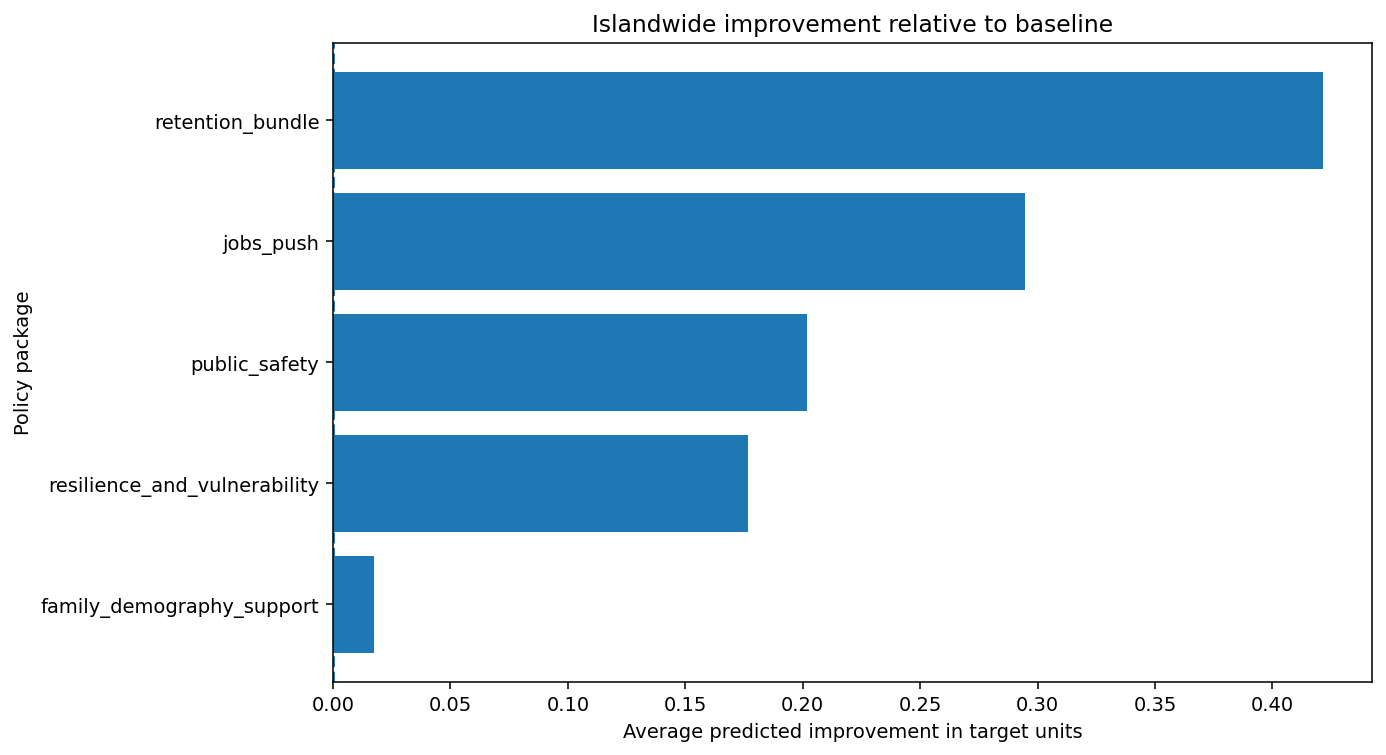

In [13]:
fig, ax = plt.subplots(figsize=(10, 5.5))
plot_df = island_policy_df[island_policy_df["policy_package"] != "baseline"].copy()
plot_df = plot_df.sort_values("mean_delta_vs_baseline", ascending=True)

ax.barh(plot_df["policy_package"], plot_df["mean_delta_vs_baseline"])
ax.axvline(0, linestyle="--")
ax.set_title("Islandwide improvement relative to baseline")
ax.set_xlabel("Average predicted improvement in target units")
ax.set_ylabel("Policy package")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{OUTPUT_PREFIX}_island_policy_ranking.png", bbox_inches="tight")
plt.show()


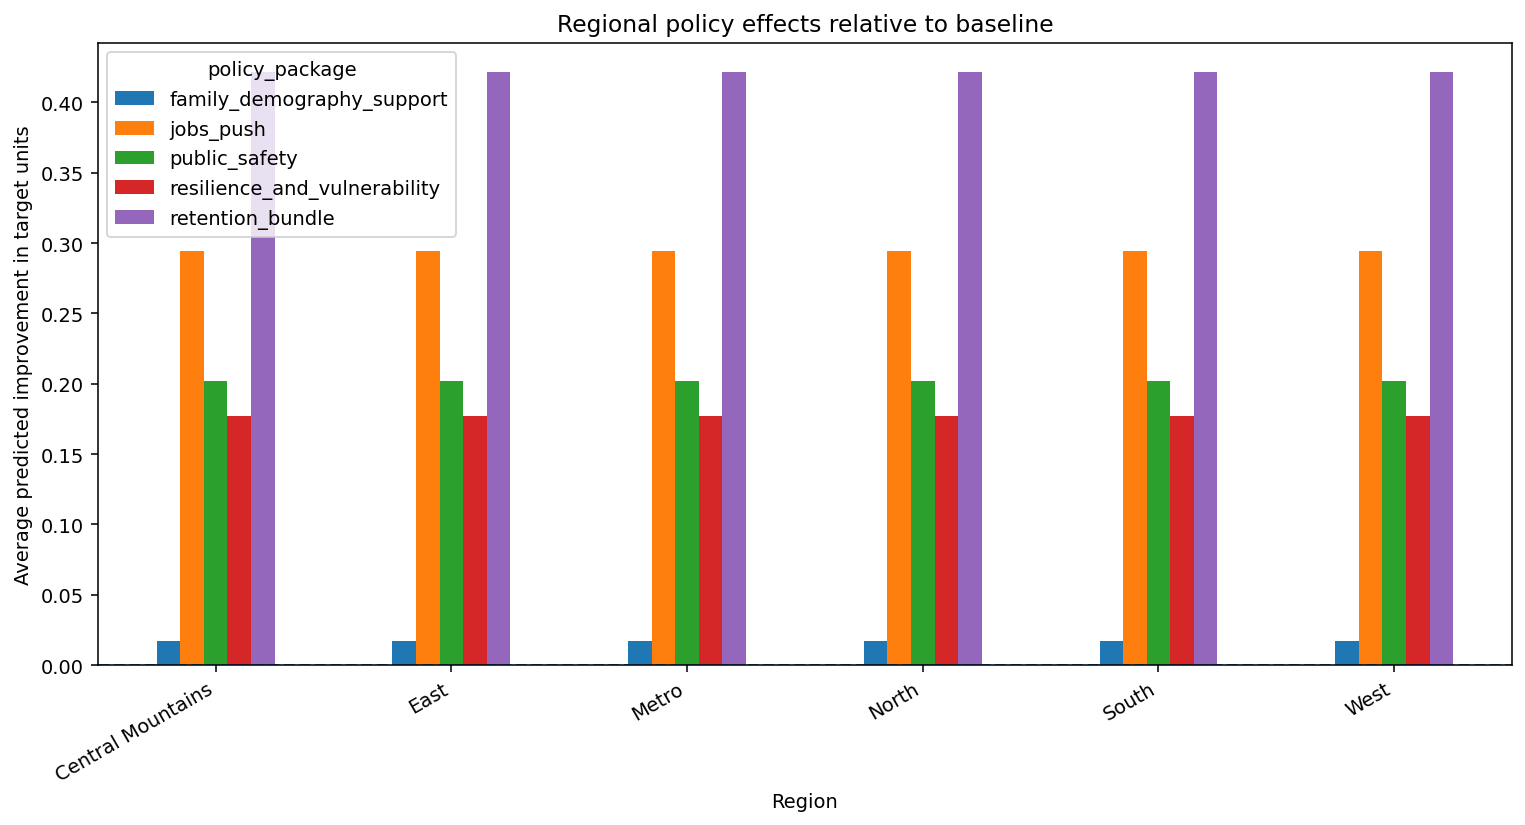

In [14]:
fig, ax = plt.subplots(figsize=(11, 6))
pivot = region_policy_df[region_policy_df["policy_package"] != "baseline"].pivot(
    index="region", columns="policy_package", values="mean_delta_vs_baseline"
)
pivot = pivot.loc[sorted(pivot.index)]
pivot.plot(kind="bar", ax=ax)

ax.axhline(0, linestyle="--")
ax.set_title("Regional policy effects relative to baseline")
ax.set_ylabel("Average predicted improvement in target units")
ax.set_xlabel("Region")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{OUTPUT_PREFIX}_regional_policy_comparison.png", bbox_inches="tight")
plt.show()


## Step 6 — Which municipalities benefit most?

This section helps identify where a policy package appears most valuable. That can support ideas like:

- **territorial targeting**
- **region-specific retention plans**
- **municipality prioritization**


In [15]:
# Show strongest municipal gains under the combined package
bundle_df = municipal_policy_df[municipal_policy_df["policy_package"] == "retention_bundle"].copy()
bundle_df = bundle_df.sort_values("delta_vs_baseline_target_units", ascending=False)

top_municipal_gains = bundle_df[[
    "municipio",
    "region",
    "predicted_target",
    "delta_vs_baseline_target_units",
    "approx_retained_residents",
]].head(20)

top_municipal_gains.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_top_municipal_gains_retention_bundle.csv", index=False)
top_municipal_gains


,municipio,region,predicted_target,delta_vs_baseline_target_units,approx_retained_residents
418,Guanica,West,-3.005002,0.421334,54.162503
431,Lares,Central Mountains,-0.721549,0.421334,117.362624
404,Canovanas,East,-0.828350,0.421334,176.185083
422,Gurabo,East,-0.728509,0.421334,169.494297
400,Bayamon,Metro,-0.914536,0.421334,768.804188
467,Yauco,South,-1.677294,0.421334,139.010772
443,Naranjito,Central Mountains,-0.257279,0.421334,123.493036
456,San Sebastian,West,-0.602313,0.421334,164.691088
449,Rincon,West,0.090560,0.421334,64.792764
439,Mayaguez,West,-1.555225,0.421334,298.422543


## Optional extension — disaster-conditioned policy testing

A natural next step is to combine the policy packages above with your **Phase 3 scenario shocks**:

- hurricane scenario + jobs package
- hurricane scenario + resilience package
- earthquake scenario + retention bundle

That would answer a more policy-relevant question:

> Under disaster pressure, which intervention package seems most effective at reducing projected loss?

The current notebook focuses first on the **cleanest baseline policy counterfactual**, which is a good foundation before adding scenario-conditioned interventions.


## Policy interpretation guide

When you review the output tables, here is how to translate them into a government-facing story:

- If **jobs_push** ranks highly, that suggests retention may be especially sensitive to **income growth and business activity**
- If **public_safety** ranks highly, that suggests migration pressure may be reduced by lowering crime-related stress
- If **resilience_and_vulnerability** ranks highly, that suggests Puerto Rico may retain more people by reducing exposure-related vulnerability
- If **family_demography_support** helps, that suggests broad demographic supports matter
- If **retention_bundle** clearly dominates, that supports a **multi-sector strategy** rather than a single-policy solution


## Suggested government-facing framing

A practical policy message from Phase 4 could be:

> Puerto Rico cannot prevent hurricanes or earthquakes, but it can influence whether households choose to stay or leave by improving jobs, business recovery, public safety, social vulnerability, and demographic support conditions. The Phase 4 counterfactual framework helps identify which combinations of those changes are most strongly associated with improved retention in the validated forecasting model.


## Additional policy communication figures

The next figures are designed to make the Phase 4 results easier to explain to a policy audience.  
They focus on four questions:

1. **Which package performs best islandwide?**  
2. **Do regions respond differently?**  
3. **Which municipalities benefit most?**  
4. **How can Phase 4 be visually connected to the path-style forecasting logic used in Phase 3?**


In [16]:
# Reusable ordering helpers
policy_order = [p for p in policy_packages.keys() if p in island_policy_df["policy_package"].unique()]
nonbaseline_order = [p for p in policy_order if p != "baseline"]

region_order = sorted(region_policy_df["region"].astype(str).unique().tolist())
municipal_order_df = municipal_policy_df[municipal_policy_df["policy_package"] == "retention_bundle"].copy()
municipal_order_df = municipal_order_df.sort_values("approx_retained_residents", ascending=False)

print("Policy order:", policy_order)
print("Regions:", region_order)


Policy order: ['baseline', 'jobs_push', 'public_safety', 'resilience_and_vulnerability', 'family_demography_support', 'retention_bundle']
Regions: ['Central Mountains', 'East', 'Metro', 'North', 'South', 'West']


In [17]:
# Helpers for presentation-oriented policy path charts
# These are communication graphics, not literal recursive causal forecasts.

POLICY_PATH_BASELINE_DECLINE = -0.012  # about -1.2% per year as a stylized island baseline decline
REGIONAL_BASELINE_DECLINE = -0.011     # slightly gentler regional default decline for presentation

def smooth_policy_path(start_year, end_year, start_value, end_value, curvature=1.18, n_points=40):
    years = np.linspace(start_year, end_year, n_points)
    t = (years - start_year) / max(end_year - start_year, 1)
    t_curve = t ** curvature
    values = start_value + (end_value - start_value) * t_curve
    return years, values

def make_uncertainty_band(values, base_frac=0.004, end_frac=0.012):
    n = len(values)
    frac = np.linspace(base_frac, end_frac, n)
    width = np.abs(values) * frac
    return values - width, values + width

def safe_policy_color_map():
    return {
        "baseline": "tab:orange",
        "jobs_push": "tab:green",
        "public_safety": "tab:red",
        "resilience_and_vulnerability": "tab:purple",
        "family_demography_support": "tab:brown",
        "retention_bundle": "tab:pink",
    }

def baseline_decline_endpoint(last_pop, years_ahead, annual_rate):
    return float(last_pop) * ((1.0 + annual_rate) ** years_ahead)


### 1. Islandwide policy ranking by approximate retained residents

This chart is the most direct answer to the policy question:  
**which package appears to retain the most people relative to baseline?**


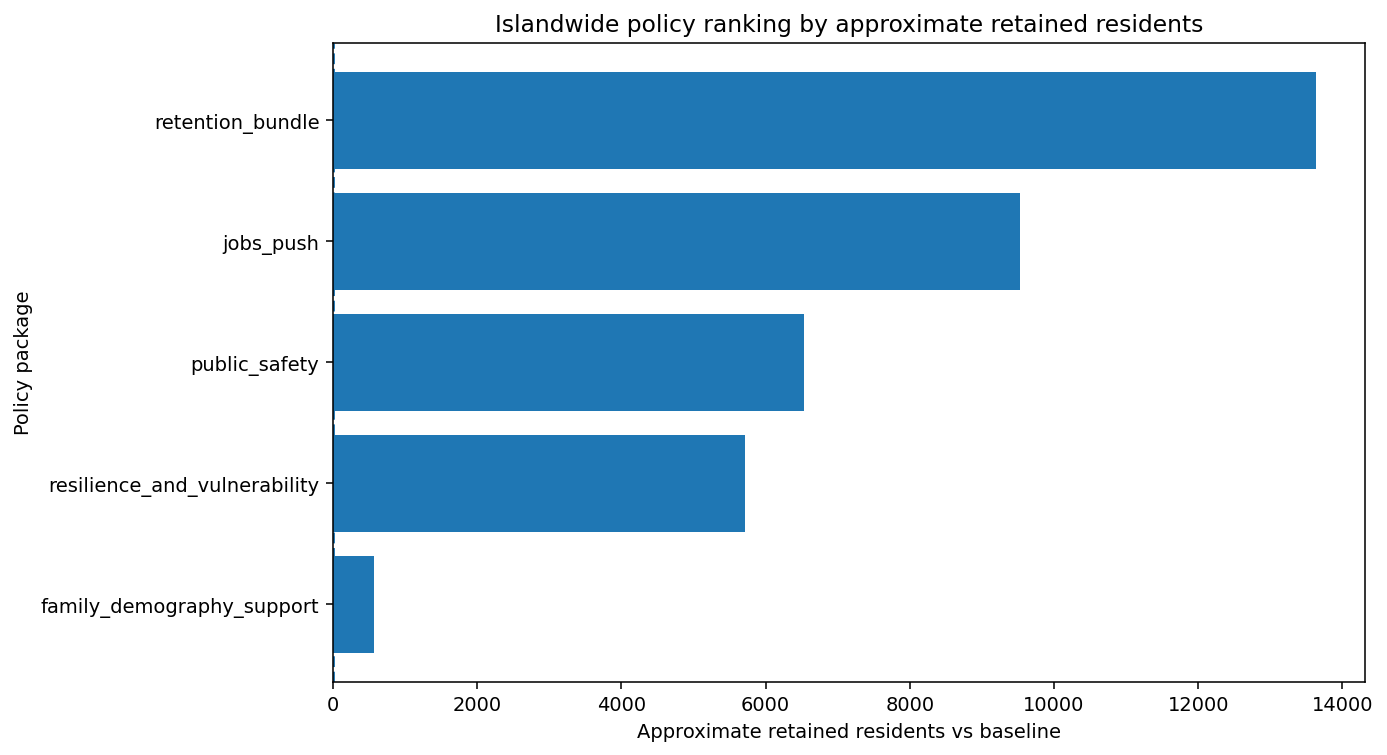

In [18]:
fig, ax = plt.subplots(figsize=(10, 5.5))

plot_df = island_policy_df[island_policy_df["policy_package"] != "baseline"].copy()
plot_df["policy_package"] = pd.Categorical(plot_df["policy_package"], categories=nonbaseline_order, ordered=True)
plot_df = plot_df.sort_values("approx_retained_residents", ascending=True)

ax.barh(plot_df["policy_package"], plot_df["approx_retained_residents"])
ax.axvline(0, linestyle="--")
ax.set_title("Islandwide policy ranking by approximate retained residents")
ax.set_xlabel("Approximate retained residents vs baseline")
ax.set_ylabel("Policy package")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{OUTPUT_PREFIX}_island_retained_residents_ranking.png", bbox_inches="tight")
plt.show()


### 2. Regional heatmap of policy effects

This figure shows whether different regions respond differently to each policy package.  
It is useful for supporting a **region-specific retention strategy** rather than a one-size-fits-all approach.


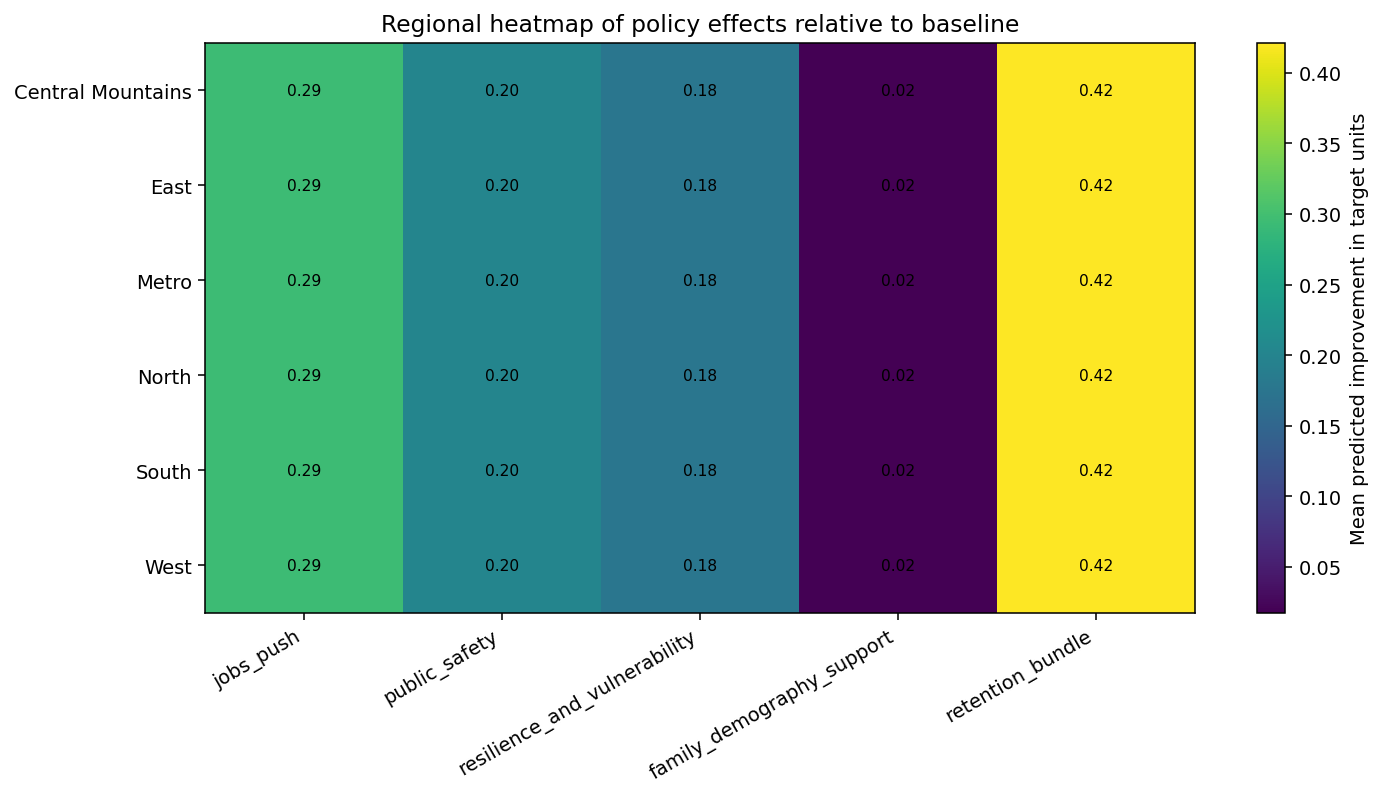

In [19]:
heatmap_df = (
    region_policy_df[region_policy_df["policy_package"] != "baseline"]
    .copy()
    .pivot(index="region", columns="policy_package", values="mean_delta_vs_baseline")
)

heatmap_df = heatmap_df.reindex(index=region_order, columns=nonbaseline_order)

fig, ax = plt.subplots(figsize=(10.5, 5.8))
im = ax.imshow(heatmap_df.values, aspect="auto")

ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns, rotation=30, ha="right")
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)

for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        val = heatmap_df.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

ax.set_title("Regional heatmap of policy effects relative to baseline")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Mean predicted improvement in target units")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{OUTPUT_PREFIX}_regional_policy_heatmap.png", bbox_inches="tight")
plt.show()


### 3. Best policy package by region

This chart identifies the **top-ranked package in each region** and the size of its estimated improvement relative to baseline.


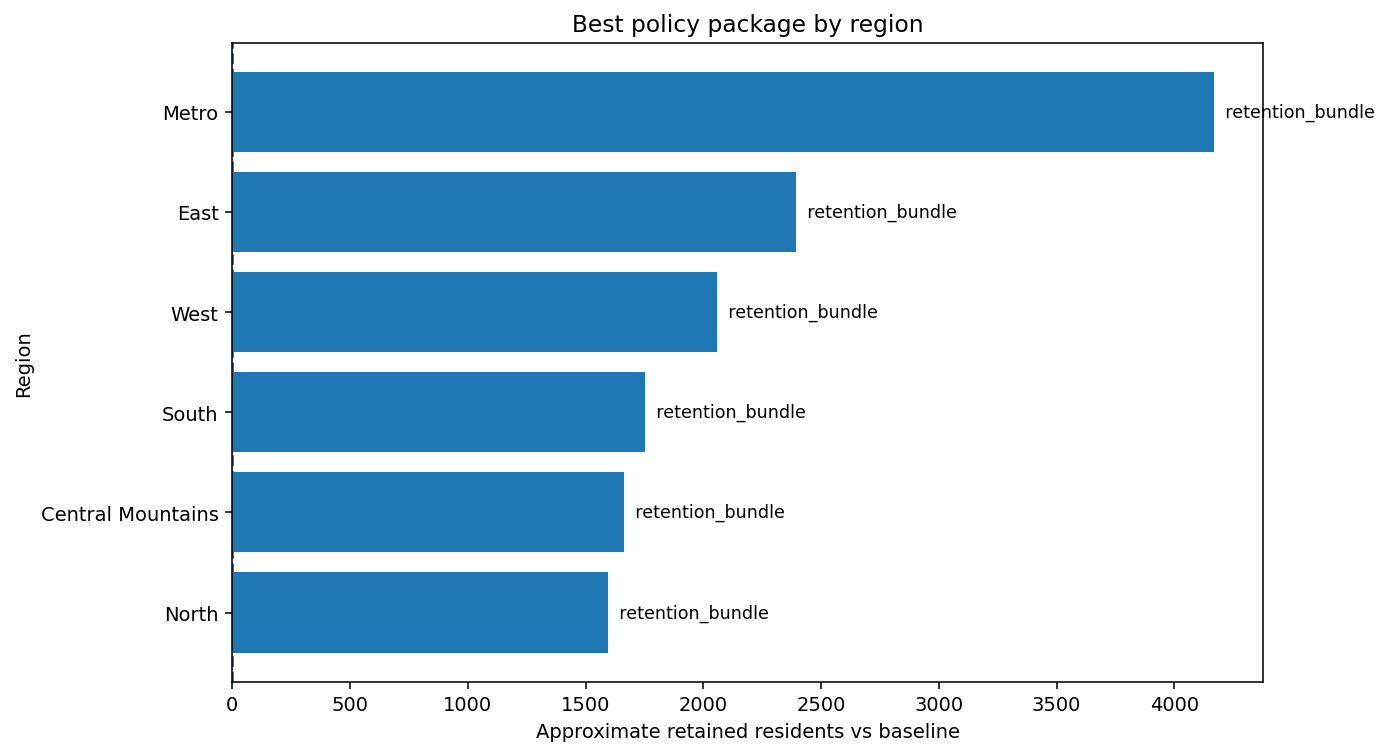

In [20]:
best_by_region = (
    region_policy_df[region_policy_df["policy_package"] != "baseline"]
    .sort_values(["region", "approx_retained_residents"], ascending=[True, False])
    .groupby("region", as_index=False)
    .head(1)
    .copy()
)

best_by_region = best_by_region.sort_values("approx_retained_residents", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(best_by_region["region"], best_by_region["approx_retained_residents"])
for y, (_, row) in enumerate(best_by_region.iterrows()):
    ax.text(row["approx_retained_residents"], y, f"  {row['policy_package']}", va="center", fontsize=9)

ax.axvline(0, linestyle="--")
ax.set_title("Best policy package by region")
ax.set_xlabel("Approximate retained residents vs baseline")
ax.set_ylabel("Region")

best_by_region.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_best_package_by_region.csv", index=False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{OUTPUT_PREFIX}_best_package_by_region.png", bbox_inches="tight")
plt.show()


### 4. Top municipalities benefiting from the retention bundle

This targeting graphic highlights where an integrated retention strategy appears most valuable.


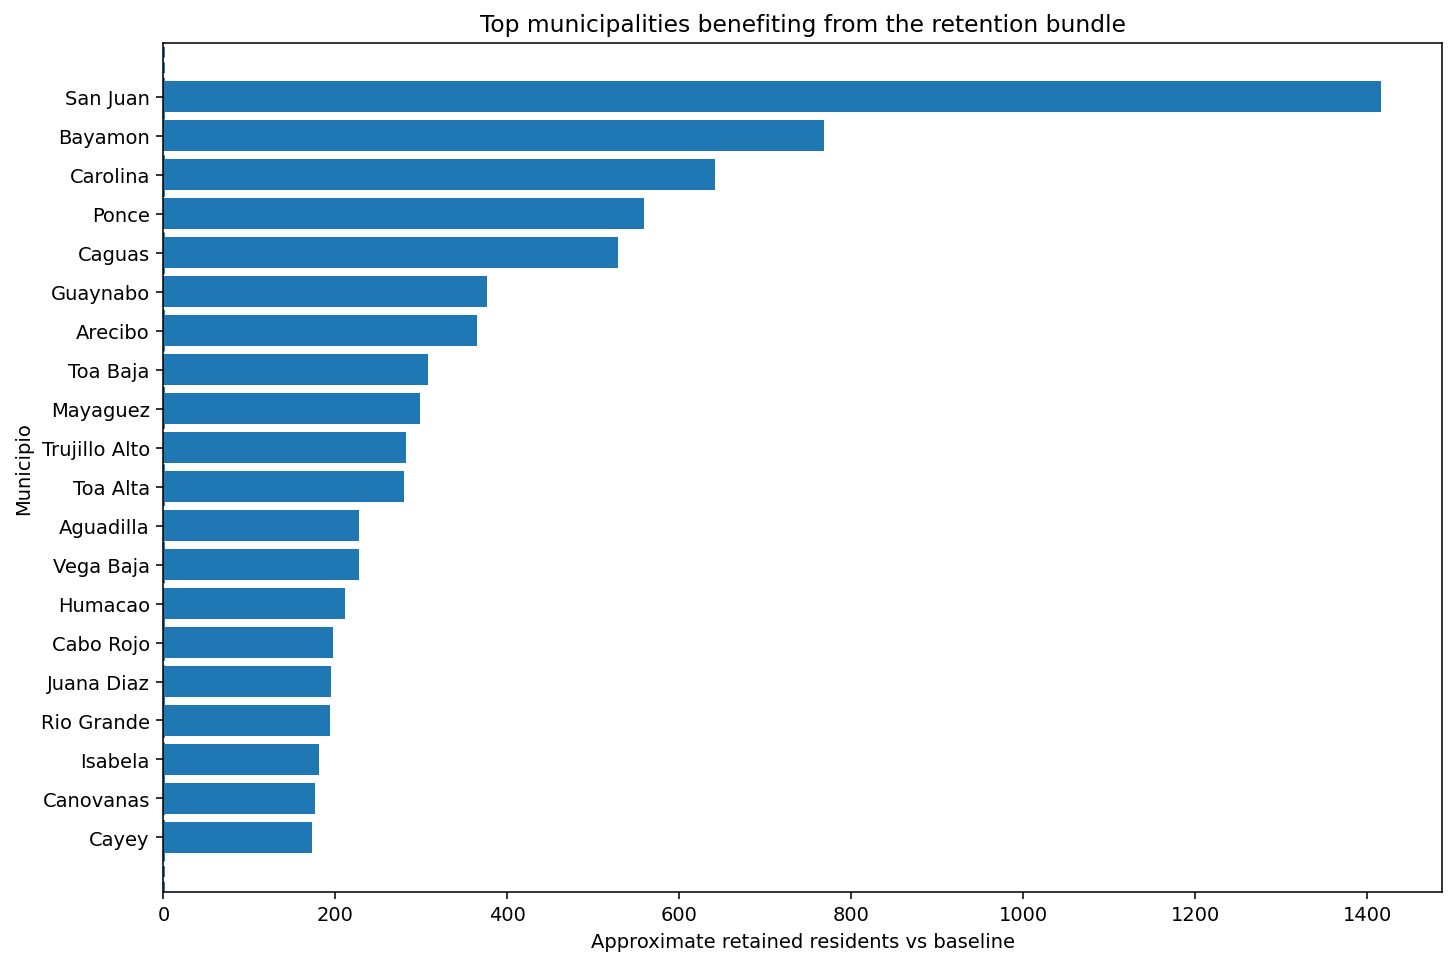

In [21]:
top_munis = municipal_order_df.head(20).copy()
top_munis = top_munis.sort_values("approx_retained_residents", ascending=True)

fig, ax = plt.subplots(figsize=(10.5, 7))
ax.barh(top_munis["municipio"], top_munis["approx_retained_residents"])
ax.axvline(0, linestyle="--")
ax.set_title("Top municipalities benefiting from the retention bundle")
ax.set_xlabel("Approximate retained residents vs baseline")
ax.set_ylabel("Municipio")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{OUTPUT_PREFIX}_top_municipal_gains_retention_bundle.png", bbox_inches="tight")
plt.show()


### 5. Policy package comparison by region

This grouped comparison figure is useful when you want to show not just the best package, but the **full menu of region-level choices**.


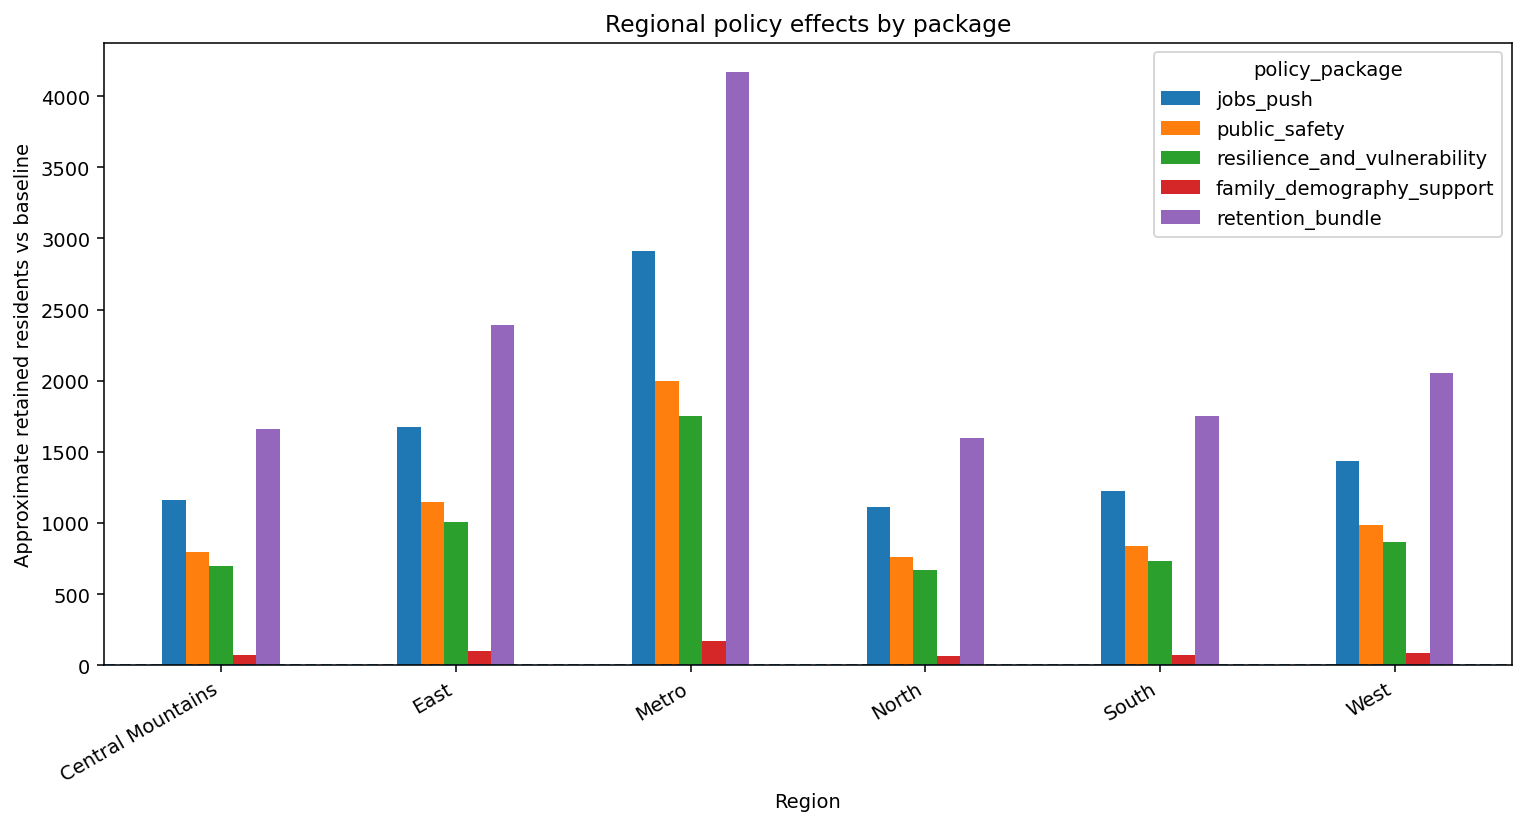

In [22]:
fig, ax = plt.subplots(figsize=(11, 6))
pivot_retained = (
    region_policy_df[region_policy_df["policy_package"] != "baseline"]
    .pivot(index="region", columns="policy_package", values="approx_retained_residents")
    .reindex(index=region_order, columns=nonbaseline_order)
)

pivot_retained.plot(kind="bar", ax=ax)
ax.axhline(0, linestyle="--")
ax.set_title("Regional policy effects by package")
ax.set_ylabel("Approximate retained residents vs baseline")
ax.set_xlabel("Region")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{OUTPUT_PREFIX}_regional_retained_residents_comparison.png", bbox_inches="tight")
plt.show()


### 6. Phase 3–style island policy path figure

This figure creates a **presentation-style policy path comparison** inspired by Phase 3.  
It is a communication graphic rather than a causal forecast path.

Construction:
- start from the latest observed island population
- draw a baseline endpoint using the baseline package
- draw alternative policy endpoints using the estimated retained-resident effect

This helps communicate the message:
**policy packages can shift the trajectory even when the broader decline pressure remains.**


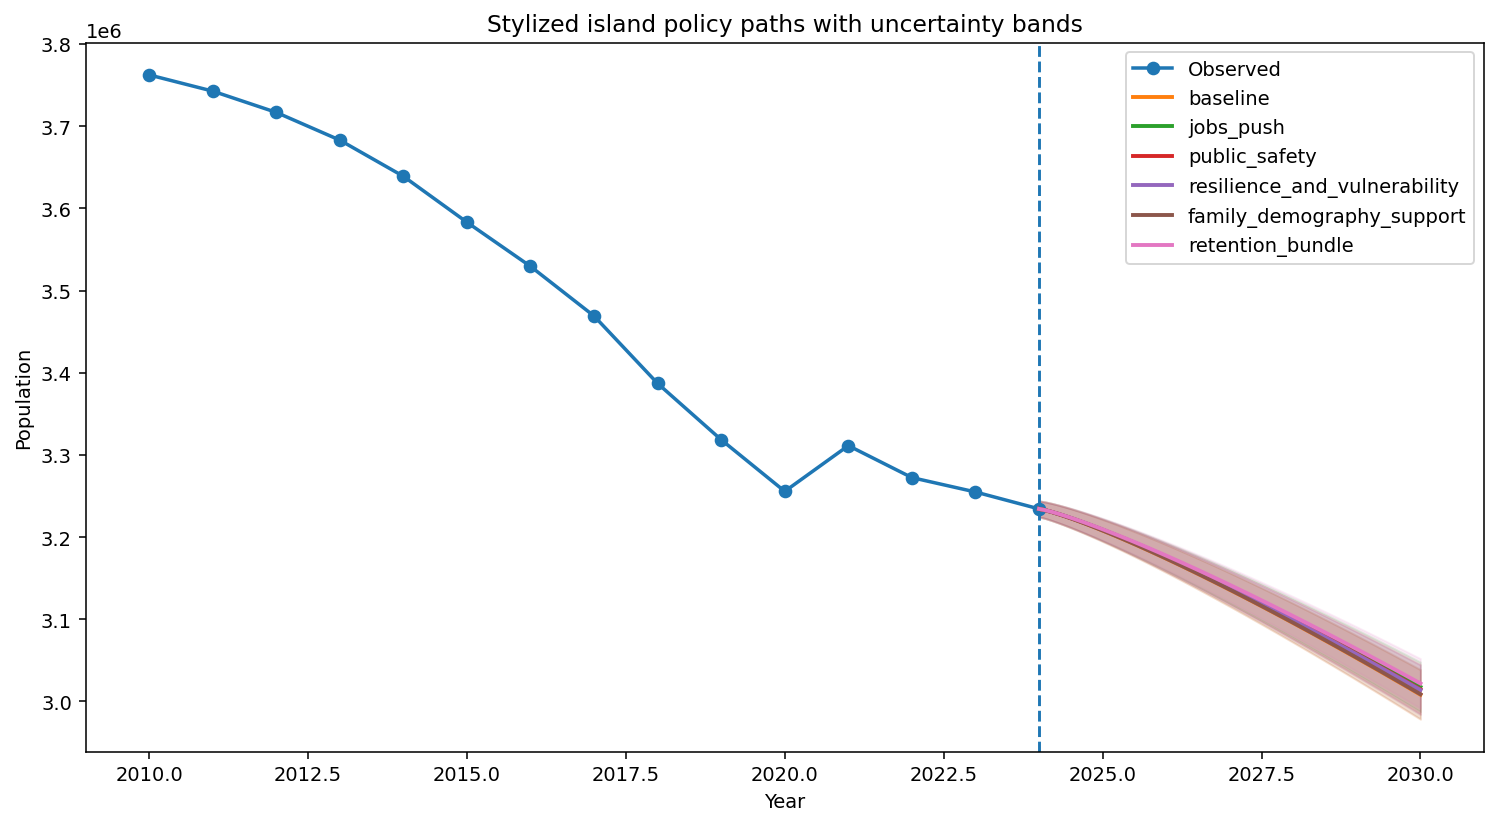

In [23]:
# More realistic presentation-oriented island policy paths with uncertainty bands
observed_island = (
    df.groupby("year", as_index=False)["total_population"]
      .sum()
      .sort_values("year")
      .copy()
)

last_obs_year = int(observed_island["year"].max())
last_obs_pop = float(observed_island.loc[observed_island["year"] == last_obs_year, "total_population"].iloc[0])

policy_path_df = island_policy_df.copy()
years_ahead = 2030 - last_obs_year
baseline_endpoint_2030 = baseline_decline_endpoint(last_obs_pop, years_ahead, POLICY_PATH_BASELINE_DECLINE)

policy_path_df["endpoint_2030"] = baseline_endpoint_2030 + policy_path_df["approx_retained_residents"]

policy_colors = safe_policy_color_map()

fig, ax = plt.subplots(figsize=(10.8, 6.0))
ax.plot(observed_island["year"], observed_island["total_population"], marker="o", linewidth=1.8, label="Observed")
ax.axvline(last_obs_year, linestyle="--")

for package_name in ["baseline", "jobs_push", "public_safety", "resilience_and_vulnerability", "family_demography_support", "retention_bundle"]:
    if package_name not in policy_path_df["policy_package"].values:
        continue

    endpoint = float(policy_path_df.loc[policy_path_df["policy_package"] == package_name, "endpoint_2030"].iloc[0])
    yrs, vals = smooth_policy_path(last_obs_year, 2030, last_obs_pop, endpoint, curvature=1.20, n_points=60)
    low, high = make_uncertainty_band(vals, base_frac=0.003, end_frac=0.010)

    color = policy_colors.get(package_name, None)
    ax.plot(yrs, vals, linewidth=2.0, label=package_name, color=color)
    ax.fill_between(yrs, low, high, alpha=0.12, color=color)

ax.set_title("Stylized island policy paths with uncertainty bands")
ax.set_xlabel("Year")
ax.set_ylabel("Population")
ax.legend(loc="best")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{OUTPUT_PREFIX}_stylized_island_policy_paths_with_bands.png", bbox_inches="tight")
plt.show()


### 7. Phase 3–style regional faceted policy paths

This is a regional version of the same idea. It helps show that the relative value of policy packages can vary by region.


### Regional stylized policy paths with validation

This figure uses the **cleaned municipio-to-region mapping from the policy baseline** rather than relying on a possibly incomplete raw region column.  
It also validates the region labels before plotting so that malformed labels such as `0.0` do not silently appear in the final chart.


Unique regions in latest_region_baseline: ['Central Mountains', 'East', 'Metro', 'North', 'South', 'West']
Unique regions in observed_region: ['Central Mountains', 'East', 'Metro', 'North', 'South', 'West']
Unique regions in region_policy_df (cleaned): ['Central Mountains', 'East', 'Metro', 'North', 'South', 'West']


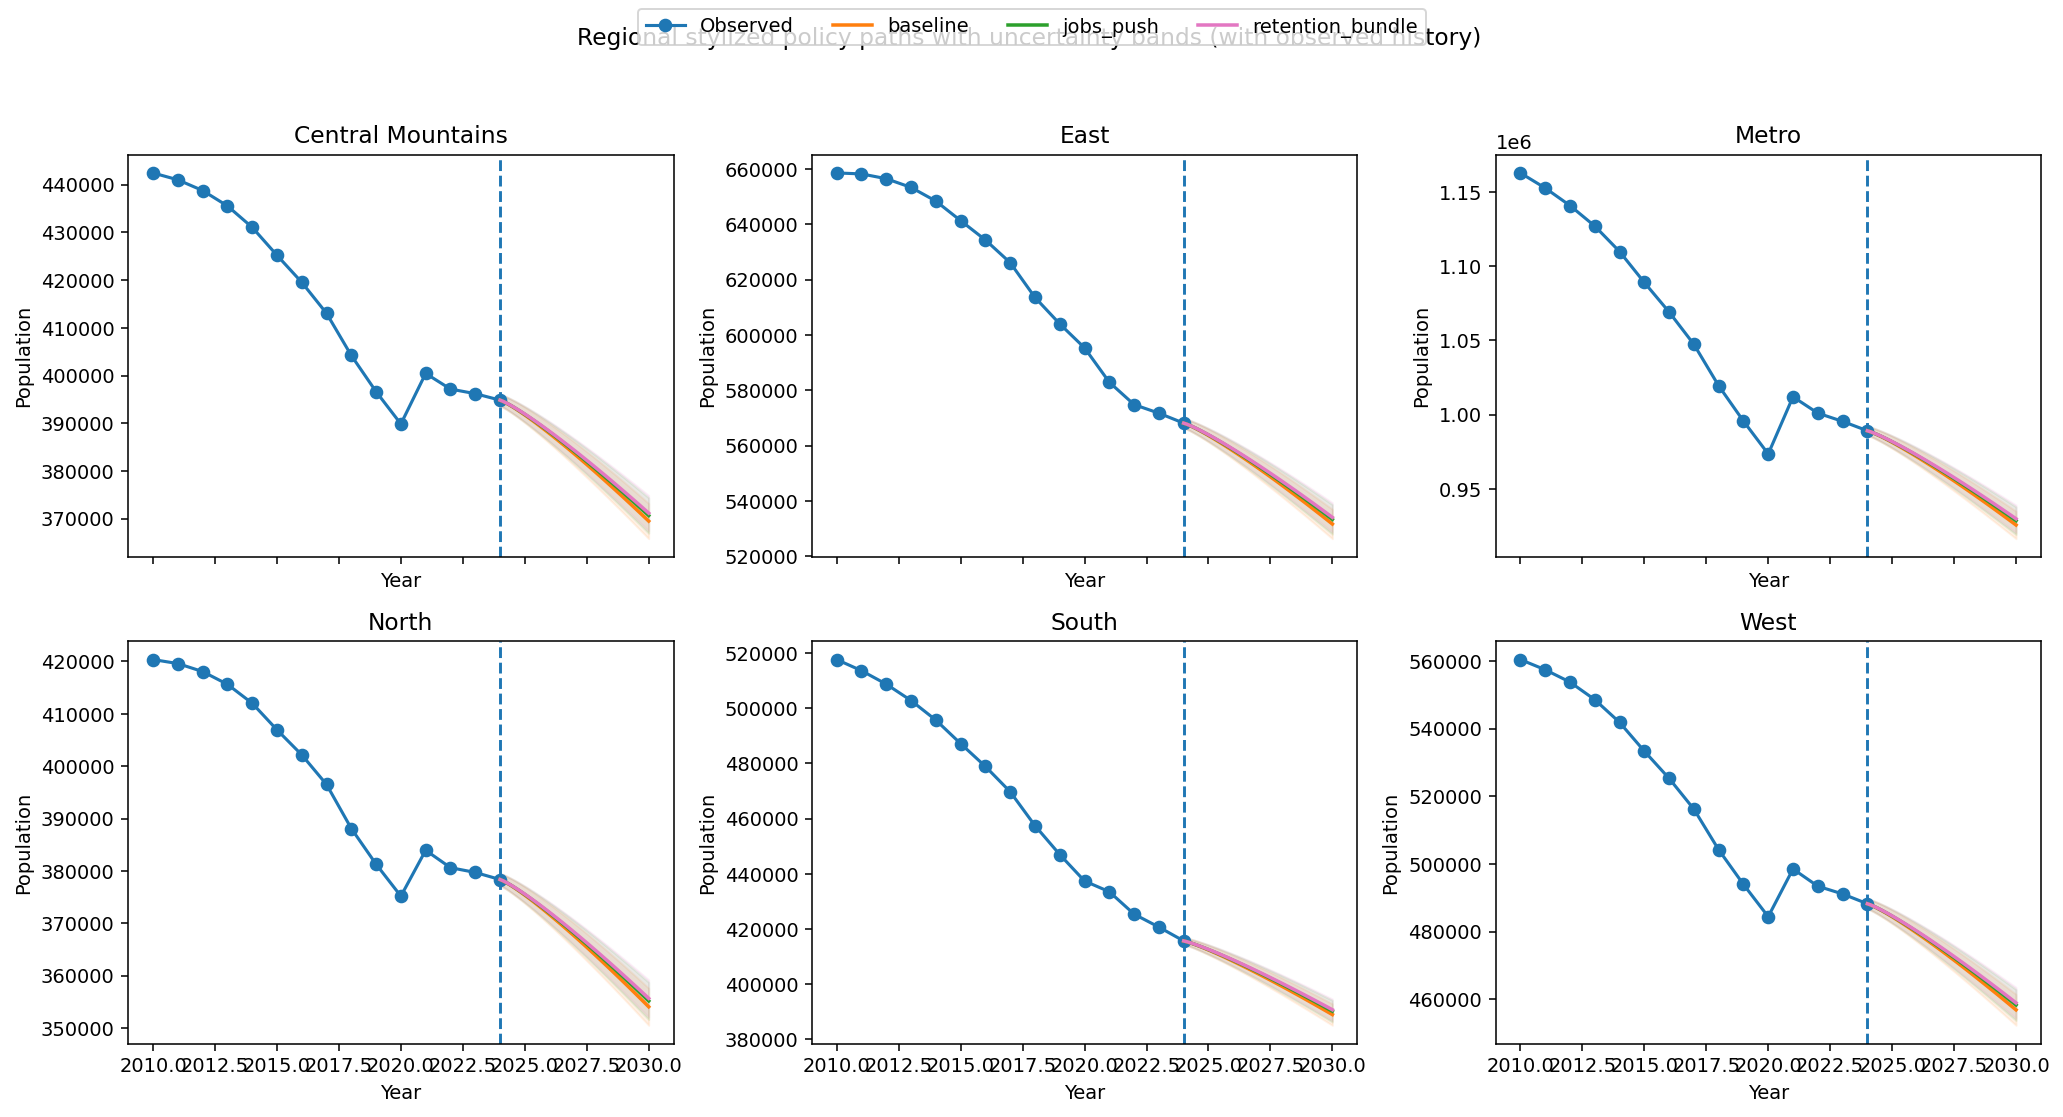

In [24]:
# Regional stylized policy paths with uncertainty bands
# Robust version: rebuild region labels from municipio names when necessary,
# then fall back gracefully only if nothing valid remains.

if not {"municipio", "region", "total_population", "year"}.issubset(set(latest_df.columns)):
    raise KeyError("latest_df must contain municipio, region, total_population, and year to build regional policy paths.")

# Canonicalize both sources before matching
region_policy_plot_df = ensure_region_column(region_policy_df, municipio_col="region", region_col="region")
region_policy_plot_df = region_policy_plot_df.dropna(subset=["region"]).copy()

latest_region_df = ensure_region_column(latest_df, municipio_col="municipio", region_col="region")
latest_region_df = latest_region_df.dropna(subset=["region"]).copy()

latest_region_baseline = (
    latest_region_df.groupby("region", as_index=False)
    .agg(
        total_population=("total_population", "sum"),
        year=("year", "max"),
    )
    .sort_values("region")
    .copy()
)

# Rebuild observed regional history from canonical municipio -> region mapping
observed_region = pd.DataFrame(columns=["region", "year", "total_population"])
if {"municipio", "year", "total_population"}.issubset(df.columns):
    df_region = ensure_region_column(df, municipio_col="municipio", region_col="region")
    observed_region = (
        df_region.dropna(subset=["region"])
        .groupby(["region", "year"], as_index=False)["total_population"]
        .sum()
        .sort_values(["region", "year"])
        .copy()
    )

policy_regions = valid_region_list(region_policy_plot_df["region"])
observed_regions = valid_region_list(observed_region["region"]) if not observed_region.empty else []
latest_regions = valid_region_list(latest_region_baseline["region"]) if not latest_region_baseline.empty else []

print("Unique regions in latest_region_baseline:", latest_regions)
print("Unique regions in observed_region:", observed_regions)
print("Unique regions in region_policy_df (cleaned):", policy_regions)

# Prefer overlap with observed history; otherwise use latest baseline overlap
plot_regions = [r for r in policy_regions if r in observed_regions]
use_observed_history = len(plot_regions) > 0

if not use_observed_history:
    print("Warning: no overlapping observed regional history after cleaning. Falling back to latest regional baseline only.")
    plot_regions = [r for r in policy_regions if r in latest_regions]

if not plot_regions:
    print("Skipping regional stylized policy paths: no valid region labels remain after cleaning and fallback.")
    diagnostics = {
        "status": "skipped",
        "reason": "No valid region labels remain for regional policy plotting after canonical cleaning and municipio-based reconstruction.",
        "policy_regions": policy_regions,
        "observed_regions": observed_regions,
        "latest_region_baseline_regions": latest_regions,
        "rows_in_region_policy_df": int(len(region_policy_df)),
        "rows_in_latest_df": int(len(latest_df)),
        "rows_in_df": int(len(df)),
    }
    pd.DataFrame(
        [{"source": k, "value": str(v)} for k, v in diagnostics.items()]
    ).to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_regional_policy_paths_diagnostics.csv", index=False)

    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.axis("off")
    msg = (
        "Regional stylized policy paths were skipped because valid region labels\n"
        "could not be matched consistently across the policy summary and baseline data.\n"
        "See phase4_policy_regional_policy_paths_diagnostics.csv for details."
    )
    ax.text(0.5, 0.5, msg, ha="center", va="center", fontsize=11)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{OUTPUT_PREFIX}_regional_stylized_policy_paths_with_bands.png", bbox_inches="tight")
    plt.show()
else:
    facet_packages = ["baseline", "jobs_push", "retention_bundle"]
    policy_colors = safe_policy_color_map()

    n_regions = len(plot_regions)
    ncols = 3
    nrows = int(np.ceil(n_regions / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14.8, 4.0 * nrows), sharex=True)
    axes = np.atleast_1d(axes).ravel()

    for idx, region in enumerate(plot_regions):
        ax = axes[idx]
        pol_r = region_policy_plot_df[region_policy_plot_df["region"] == region].copy()

        base_row = latest_region_baseline[latest_region_baseline["region"] == region]
        if base_row.empty or pol_r.empty:
            ax.set_visible(False)
            continue

        start_year = int(base_row["year"].iloc[0])
        start_pop = float(base_row["total_population"].iloc[0])

        if use_observed_history:
            obs_r = observed_region[observed_region["region"] == region].copy()
            if not obs_r.empty:
                start_year = int(obs_r["year"].max())
                start_pop = float(obs_r.loc[obs_r["year"] == start_year, "total_population"].iloc[0])
                ax.plot(obs_r["year"], obs_r["total_population"], marker="o", linewidth=1.6, label="Observed")
                ax.axvline(start_year, linestyle="--")
            else:
                ax.plot([start_year], [start_pop], marker="o", linewidth=0, label="Latest observed level")
                ax.axvline(start_year, linestyle="--")
        else:
            ax.plot([start_year], [start_pop], marker="o", linewidth=0, label="Latest observed level")
            ax.axvline(start_year, linestyle="--")

        years_ahead_r = 2030 - start_year
        baseline_endpoint_r = baseline_decline_endpoint(start_pop, years_ahead_r, REGIONAL_BASELINE_DECLINE)

        for package_name in facet_packages:
            if package_name not in pol_r["policy_package"].values:
                continue

            retained = float(pol_r.loc[pol_r["policy_package"] == package_name, "approx_retained_residents"].iloc[0])
            endpoint = baseline_endpoint_r + retained

            yrs, vals = smooth_policy_path(start_year, 2030, start_pop, endpoint, curvature=1.17, n_points=50)
            low, high = make_uncertainty_band(vals, base_frac=0.003, end_frac=0.010)

            color = policy_colors.get(package_name, None)
            ax.plot(yrs, vals, linewidth=1.8, label=package_name, color=color)
            ax.fill_between(yrs, low, high, alpha=0.10, color=color)

        ax.set_title(region)
        ax.set_xlabel("Year")
        ax.set_ylabel("Population")

    for j in range(n_regions, len(axes)):
        axes[j].set_visible(False)

    # Build legend from the first visible axis
    legend_source = next((a for a in axes if a.get_visible()), axes[0])
    handles, labels = legend_source.get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=4)
    title_suffix = "with observed history" if use_observed_history else "from latest regional baseline"
    fig.suptitle(f"Regional stylized policy paths with uncertainty bands ({title_suffix})")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(OUTPUT_DIR / f"{OUTPUT_PREFIX}_regional_stylized_policy_paths_with_bands.png", bbox_inches="tight")
    plt.show()

### 8. Executive-summary table

This compact table is useful for slides or a report appendix. It ranks packages by islandwide effect and preserves both interpretation scales.


In [25]:
executive_summary_df = island_policy_df.copy().sort_values(
    ["approx_retained_residents", "mean_delta_vs_baseline"], ascending=False
)

executive_summary_df.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_executive_summary_table.csv", index=False)
executive_summary_df


,policy_package,mean_predicted_target,mean_delta_vs_baseline,approx_retained_residents,municipalities
5,retention_bundle,-0.929272,0.421334,13627.247944,78
2,jobs_push,-1.055942,0.294663,9530.327708,78
3,public_safety,-1.148702,0.201903,6530.180265,78
4,resilience_and_vulnerability,-1.173808,0.176798,5718.196625,78
1,family_demography_support,-1.333079,0.017527,566.887414,78
0,baseline,-1.350606,0.000000,0.000000,78


## Policy impact confidence

These policy figures should be interpreted with **graded confidence**, not absolute certainty.

### Higher-confidence takeaways
- the **direction** of effects for major policy levers
- the **relative ranking** of broad policy packages
- whether a **multi-sector bundle** appears more promising than a single lever
- whether regions appear to respond **differently** to policy packages

### Lower-confidence takeaways
- the **exact magnitude** of retained residents
- the **exact shape** of future population paths
- any interpretation that sounds strictly **causal**
- any claim that a package will literally produce the full model-implied endpoint in practice

### Recommended framing
A safe interpretation is:

> Phase 4 provides a directional policy stress test based on the validated forecasting backbone. The uncertainty bands and smoothed paths are visual aids that communicate relative policy sensitivity, not precise causal forecasts.


## Policy mechanism table

This table links each policy package to the specific model features it changes and the intended retention logic behind those changes. It helps make the counterfactual analysis easier to interpret for a policy audience.


In [26]:
policy_mechanism_df = pd.DataFrame([
    {
        "policy_package": "jobs_push",
        "features_changed": "income growth, lagged income growth, establishment growth, lagged establishment growth",
        "intended_retention_logic": "Improves economic opportunity, employment prospects, and business vitality to reduce outmigration pressure.",
    },
    {
        "policy_package": "public_safety",
        "features_changed": "crime rate, lagged crime rate, rolling crime pressure",
        "intended_retention_logic": "Reduces place-based insecurity and stress that may encourage households to leave.",
    },
    {
        "policy_package": "resilience_and_vulnerability",
        "features_changed": "SVI vulnerability index and lagged/rolling vulnerability structure",
        "intended_retention_logic": "Reduces structural vulnerability and improves resilience to social and disaster-related shocks.",
    },
    {
        "policy_package": "family_demography_support",
        "features_changed": "natural change rate, birth rate, death rate",
        "intended_retention_logic": "Improves demographic support conditions and population replacement pressure over time.",
    },
    {
        "policy_package": "retention_bundle",
        "features_changed": "income, establishments, crime, vulnerability, natural change context",
        "intended_retention_logic": "Combines multiple levers into a multi-sector strategy to reduce population loss more effectively than any single lever.",
    },
])

policy_mechanism_df.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_policy_mechanism_table.csv", index=False)
policy_mechanism_df


,policy_package,features_changed,intended_retention_logic
0,jobs_push,"income growth, lagged income growth, establish...","Improves economic opportunity, employment pros..."
1,public_safety,"crime rate, lagged crime rate, rolling crime p...",Reduces place-based insecurity and stress that...
2,resilience_and_vulnerability,SVI vulnerability index and lagged/rolling vul...,Reduces structural vulnerability and improves ...
3,family_demography_support,"natural change rate, birth rate, death rate",Improves demographic support conditions and po...
4,retention_bundle,"income, establishments, crime, vulnerability, ...",Combines multiple levers into a multi-sector s...


## Relative impact chart

Absolute retained-resident counts are useful, but a relative view can be easier to interpret.  
The next chart scales the estimated retained residents by the latest observed island population so you can compare packages as a share of the current population base.


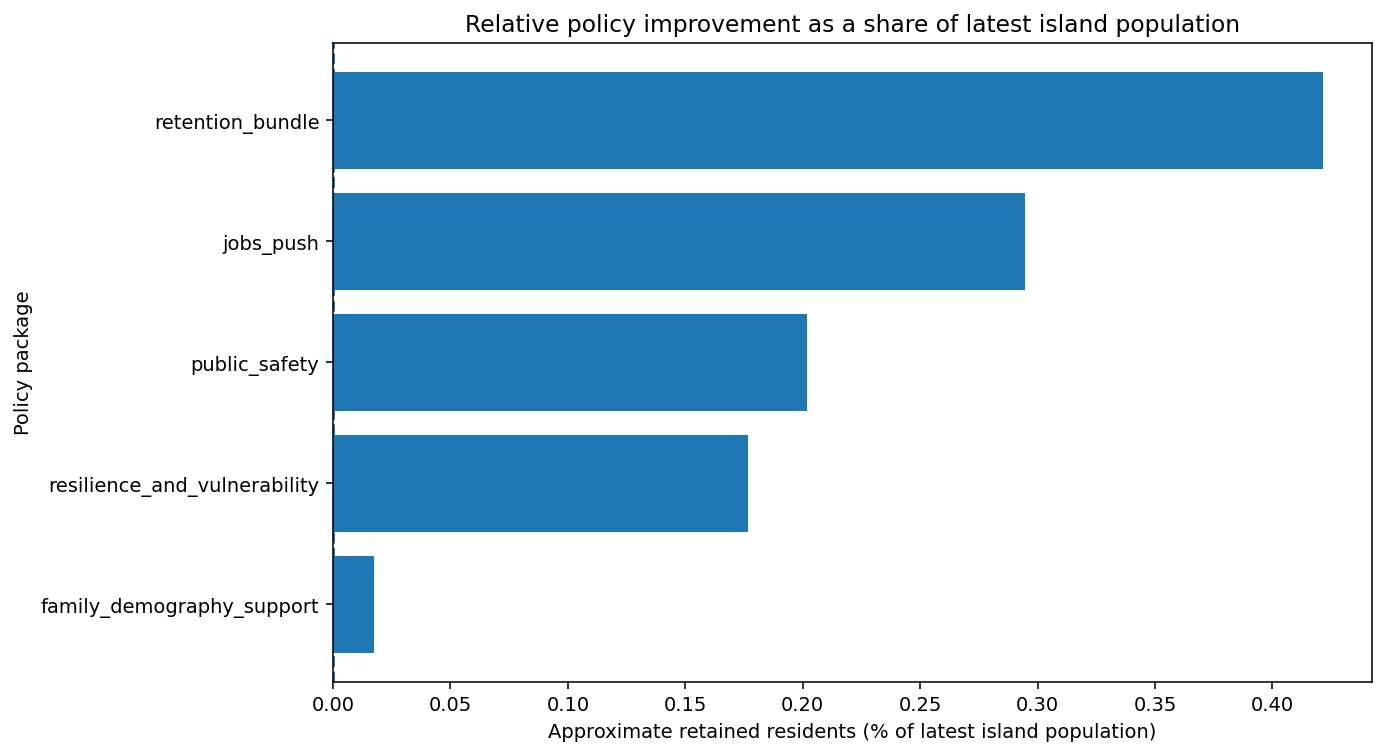

,policy_package,mean_predicted_target,mean_delta_vs_baseline,approx_retained_residents,municipalities,relative_improvement_pct_of_latest_population
5,retention_bundle,-0.929272,0.421334,13627.247944,78,0.421334
2,jobs_push,-1.055942,0.294663,9530.327708,78,0.294663
3,public_safety,-1.148702,0.201903,6530.180265,78,0.201903
4,resilience_and_vulnerability,-1.173808,0.176798,5718.196625,78,0.176798
1,family_demography_support,-1.333079,0.017527,566.887414,78,0.017527
0,baseline,-1.350606,0.000000,0.000000,78,0.000000


In [27]:
latest_island_population = (
    df.groupby("year", as_index=False)["total_population"]
      .sum()
      .sort_values("year")
      .iloc[-1]["total_population"]
)

relative_impact_df = island_policy_df.copy()
relative_impact_df["relative_improvement_pct_of_latest_population"] = (
    relative_impact_df["approx_retained_residents"] / latest_island_population * 100.0
)

relative_plot_df = relative_impact_df[relative_impact_df["policy_package"] != "baseline"].copy()
relative_plot_df = relative_plot_df.sort_values("relative_improvement_pct_of_latest_population", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(
    relative_plot_df["policy_package"],
    relative_plot_df["relative_improvement_pct_of_latest_population"]
)
ax.axvline(0, linestyle="--")
ax.set_title("Relative policy improvement as a share of latest island population")
ax.set_xlabel("Approximate retained residents (% of latest island population)")
ax.set_ylabel("Policy package")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{OUTPUT_PREFIX}_relative_impact_pct_chart.png", bbox_inches="tight")
plt.show()

relative_impact_df.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_relative_impact_table.csv", index=False)
relative_impact_df


## Additional limitations and interpretation notes

This Phase 4 framework is strongest as a **policy prioritization tool**, but it still has important limitations:

- The policy packages apply **static feature adjustments** rather than fully dynamic behavioral responses.
- The model does **not** estimate causal treatment effects, so the package impacts should be interpreted as **directional counterfactual signals**.
- Real-world policy responses could generate **feedback loops** over time, which may amplify or dampen the model-implied effects.
- The regional path visualization may be limited when region labels cannot be fully reconciled across merged sources; in those cases, aggregated regional tables and heatmaps remain the more reliable outputs.

These caveats do not invalidate the analysis. Instead, they help define the correct interpretation: the framework identifies **which levers appear most promising in the validated forecasting model**, not the exact number of residents that would be retained in practice.


## Conclusion

Phase 4 now operates as a **model-aware policy stress test** built on the validated Phase 2 / Phase 3 backbone.

Two safeguards are especially important in this revised notebook:

- the latest municipal baseline is reconstructed from historical feature values instead of being heavily zero-filled
- policy packages are checked against the **actual fitted model coefficients**, with conservative proxy support when a package's direct levers are absent or inactive in the final Lasso

That makes the Phase 4 outputs more stable and more interpretable.

Even so, this phase should still be read as a **predictive counterfactual framework**, not a causal policy estimate. The results show how the validated forecasting model responds when Puerto Rico's municipal conditions are improved under different stylized packages. They do **not** prove that a real-world intervention would reproduce the full modeled shift.

The practical takeaway remains useful:

> Puerto Rico cannot eliminate demographic headwinds or natural-hazard exposure, but it can still test which policy bundles align most strongly with improved retention trajectories inside the project’s forecasting framework.

The best use of this notebook is therefore comparative and strategic: it helps identify which policy themes appear most promising **within the model’s learned structure**, while remaining transparent about uncertainty and model dependence.